<a href="https://colab.research.google.com/github/Marco967a/Bibliothek/blob/main/ADULT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook EDA e Pulizia Dataset Adult

**Analisi Esplorativa dei Dati (EDA) e Data Cleaning**

Questo notebook esegue un'analisi esplorativa approfondita e la pulizia del dataset Adult Census Income.

---

## 1. Importazione delle Librerie e caricamento dataset

### 1.1 Importazione delle librerie

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
my_palette = [
    "#377eb8", "#e41a1c", "#4daf4a", "#984ea3", "#ff7f00",
    "#ffff33", "#a65628", "#f781bf", "#999999"
]
custom_params = {"axes.edgecolor": "black", "lines.linewidth": 2.5}
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.2, rc=custom_params, palette=my_palette)

from scipy import stats
from scipy.stats import chi2_contingency

### 1.2 Caricamento del Dataset

In [ ]:
import os

DATA_FILE = 'adult.csv'
LOCAL_PATH = os.path.join('data', DATA_FILE)
REMOTE_URL = f'https://raw.githubusercontent.com/Marco967a/Portfolio_Notebooks/main/data/{DATA_FILE}'

# Caricamento con fallback: locale se presente, altrimenti GitHub Raw (per Google Colab)
data_path = LOCAL_PATH if os.path.exists(LOCAL_PATH) else REMOTE_URL
df = pd.read_csv(data_path)
if df is None or df.empty:
    raise ValueError('Errore nel caricamento del dataset')


## 2. Esplorazione Iniziale della Struttura

In [ ]:
df.shape

(32561, 15)

In [ ]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
df.tail()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32560,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


## 3. Informazioni Generali sul Dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df.nunique()

age                  73
workclass             9
fnlwgt            21648
education            16
education.num        16
marital.status        7
occupation           15
relationship          6
race                  5
sex                   2
capital.gain        119
capital.loss         92
hours.per.week       94
native.country       42
income                2
dtype: int64

### Osservazioni

Abbiamo notato le dimensioni del dataset e osservato i valori iniziali e finali. Il totale di valori unici per feature. Di ogni colonna, abbiamo identificato il suo tipo.

---

In [ ]:
df.columns = df.columns.str.replace('.', ' ', regex=False)

Abbimo pulito il nome delle colonne

## 4. Pulizia dati

### 4.1 Rimozione dei duplicati

In [ ]:
df.drop_duplicates(inplace=True)

### 4.2 Valori mancanti

In [ ]:
mancanti = df.isnull().sum()
mancanti

age               0
workclass         0
fnlwgt            0
education         0
education num     0
marital status    0
occupation        0
relationship      0
race              0
sex               0
capital gain      0
capital loss      0
hours per week    0
native country    0
income            0
dtype: int64

Abbiamo verificato l'assenza di valori mancanti. Come abbiamo notato precedentemente, questi valori potrebbero essere rappresentati con il simbolo "?" invece che con NaN, quindi effettueremo un'analisi più approfondita.

---

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

In [ ]:
print(categorical_cols)
print(f"\nTotale: {len(categorical_cols)} feauters\n")

['workclass', 'education', 'marital status', 'occupation', 'relationship', 'race', 'sex', 'native country', 'income']

Totale: 9 feauters



In [ ]:
dfca = df[categorical_cols]
dfca.describe(include='all')

,workclass,education,marital status,occupation,relationship,race,sex,native country,income
count,32537,32537,32537,32537,32537,32537,32537,32537,32537
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22673,10494,14970,4136,13187,27795,21775,29153,24698


Abbiamo controllato i valori unici per ogni feature e la frequenza della moda

In [ ]:
for col in categorical_cols:
    print(f"\n--- {col.upper()} ---")
    value_counts = df[col].value_counts()
    print(value_counts)
    print(f"\nNumero di categorie uniche: {df[col].nunique()}")
    print("=" * 60)


--- WORKCLASS ---
workclass
Private             22673
Self-emp-not-inc     2540
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

Numero di categorie uniche: 9

--- EDUCATION ---
education
HS-grad         10494
Some-college     7282
Bachelors        5353
Masters          1722
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           645
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           332
1st-4th           166
Preschool          50
Name: count, dtype: int64

Numero di categorie uniche: 16

--- MARITAL STATUS ---
marital status
Married-civ-spouse       14970
Never-married            10667
Divorced                  4441
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spous

In [ ]:
for col in categorical_cols:
    df[col] = df[col].str.replace('-', ' ', regex=False)

### 4.3 Gestione dei Valori "?"

In [ ]:
lista_colonne = {}
for col in categorical_cols:
    conta = (df[col] == '?').sum()
    if conta > 0:
        lista_colonne[col] = conta
        percentuale = (conta / len(df)) * 100
        print(f"{col:20s}: {conta:6,} ({percentuale:5.2f}%)")

total_missing = sum(lista_colonne.values())
print(f"\n{'TOTALE':20s}: {total_missing:6,} valori '?' trovati")

workclass           :  1,836 ( 5.64%)
occupation          :  1,843 ( 5.66%)
native country      :    582 ( 1.79%)

TOTALE              :  4,261 valori '?' trovati


In [ ]:
df.drop(df[(df['workclass'] == '?') & (df['occupation'] == '?') & (df['native country'] == '?')].index, inplace=True)

In [ ]:
while (df == '?').any().any():
    # Itera su tutte le colonne
    for col in df.columns:
        # Controlla se la colonna contiene '?'
        if (df[col] == '?').any():
            # Estrai solo i valori NON mancanti (escludi '?')
            valori_reali = df[col][df[col] != '?']

            # Crea maschera per i valori mancanti
            maschera = df[col] == '?'

            # Sostituisci con campionamento casuale
            df.loc[maschera, col] = valori_reali.sample(
                n=maschera.sum(),
                replace=True,
                random_state=None  # Cambia seed ogni iterazione
            ).values

In [ ]:
for col in categorical_cols:
    conta = (df[col] == '?').sum()
    print(f"{col:20s}: {conta} valori '?' rimasti")

workclass           : 0 valori '?' rimasti
education           : 0 valori '?' rimasti
marital status      : 0 valori '?' rimasti
occupation          : 0 valori '?' rimasti
relationship        : 0 valori '?' rimasti
race                : 0 valori '?' rimasti
sex                 : 0 valori '?' rimasti
native country      : 0 valori '?' rimasti
income              : 0 valori '?' rimasti


### 4.4 Gestione outliers

In [ ]:
outlier = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    sotto = Q1 - 1.5 * IQR
    sopra = Q3 + 1.5 * IQR

    outliers = df[(df[col] < sotto) | (df[col] > sopra)]
    n_outliers = len(outliers)
    percentuale = (n_outliers / len(df)) * 100

    outlier = {
        'N. Outliers': n_outliers,
        'Percentuale': percentuale,
        'Baffo inferiore': sotto,
        'Baffo superiore': sopra
    }

    print(f"{col}:")
    print(f"  Limiti: [{sotto:.2f}, {sopra:.2f}]")
    print(f"  Outliers: {n_outliers:,} ({percentuale:.2f}%)")

age:
  Limiti: [-2.00, 78.00]
  Outliers: 141 (0.43%)
fnlwgt:
  Limiti: [-60985.62, 415773.38]
  Outliers: 992 (3.05%)
education num:
  Limiti: [4.50, 16.50]
  Outliers: 1,190 (3.66%)
capital gain:
  Limiti: [0.00, 0.00]
  Outliers: 2,709 (8.33%)
capital loss:
  Limiti: [0.00, 0.00]
  Outliers: 1,517 (4.67%)
hours per week:
  Limiti: [32.50, 52.50]
  Outliers: 8,993 (27.66%)


## Resoconto del Contenuto del Dataset

### Descrizione Generale

**Dimensioni del dataset:**
- **Righe**: 32.510 record (dopo rimozione duplicati)
- **Colonne**: 15 variabili (14 features + 1 target)

---

### Descrizione delle Variabili

#### Variabili Demografiche

| Colonna | Tipo | Descrizione |
|---------|------|-------------|
| **age** | Numerica | Età dell'individuo in anni |
| **race** | Categorica | Etnia (White, Black, Asian-Pac-Islander, Amer-Indian-Eskimo, Other) |
| **sex** | Categorica | Genere (Male, Female) |
| **native country** | Categorica | Paese di origine (42 categorie) |

#### Variabili Lavorative

| Colonna | Tipo | Descrizione |
|---------|------|-------------|
| **workclass** | Categorica | Tipo di impiego (Private, Self-emp-not-inc, Local-gov, State-gov, Federal-gov, ecc.) - 9 categorie |
| **occupation** | Categorica | Occupazione lavorativa (Prof-specialty, Craft-repair, Exec-managerial, ecc.) - 15 categorie |
| **hours per week** | Numerica | Ore lavorate settimanalmente |
| **capital gain** | Numerica | Guadagni da capitale |
| **capital loss** | Numerica | Perdite da capitale |

#### Variabili Educative e Sociali

| Colonna | Tipo | Descrizione |
|---------|------|-------------|
| **education** | Categorica | Livello di istruzione - 16 categorie |
| **education num** | Numerica | Rappresentazione numerica del livello di istruzione |
| **marital status** | Categorica | Stato civile - 7 categorie |
| **relationship** | Categorica | Ruolo familiare - 6 categorie |

#### Variabile Target

| Colonna | Tipo | Descrizione |
|---------|------|-------------|
| **income** | Categorica | Classe di reddito: <=50K* o *>50K* |



**Qualità dei dati:** Alta - nessun valore mancante residuo, duplicati rimossi, formattazione consistente.

---

### Osservazioni
Il dataset presenta "?" solo in 3 colonne e sono stati sostituiti con le categorie presenti nel dataset mantenendo la loro distribuzione.  

Questa scelta è stata fatta per evitare l'assegnazione alla categora più frequente per evitare sovraffolamento della categoria e mantiene valori esistenti senza crearne di nuove. L'eliminazione dei record avrebbe comportato la riduzione del 5,6 % del dataset, riduzione significativa.
  
Il testo è stato formattato con la rimozione del trattino che identificava lo spazio tra le parole. Sono stati rimosse le righe duplicate che potrebbero portare a sovrastimare l'importanza di certi pattern nei dati.

#### Outliers  

Gli outlier rappresentano casi reali e legittimi che potrebbero presentarsi in fase di predizione. Eliminarli, anche se a favore di una distribuzione più uniforme dei dati.

---

## 5. EDA

In [ ]:
print(numerical_cols)
print(f"\nTotale: {len(numerical_cols)} feauters\n")

['age', 'fnlwgt', 'education num', 'capital gain', 'capital loss', 'hours per week']

Totale: 6 feauters



In [ ]:
for col in numerical_cols:
    print(f"\n{'='*60}")
    print(f"Variabile: {col.upper()}")
    print(f"{'='*60}")

    stats_dict = {
        'Count': df[col].count(),
        'Media': df[col].mean(),
        'Mediana': df[col].median(),
        'Moda': df[col].mode()[0] if len(df[col].mode()) > 0 else np.nan,
        'Dev. Standard': df[col].std(),
        'Coefficiente di Variazione': df[col].std() / df[col].mean() if df[col].mean() != 0 else np.nan,
        'Minimo': df[col].min(),
        'Massimo': df[col].max(),
        'Range': df[col].max() - df[col].min(),
        'Q1 (25%)': df[col].quantile(0.25),
        'Q3 (75%)': df[col].quantile(0.75),
        'IQR': df[col].quantile(0.75) - df[col].quantile(0.25),
        'Skewness': df[col].skew(),
        'Kurtosis': df[col].kurtosis()
    }

    for key, value in stats_dict.items():
        print(f"{key:30s}: {value:,.2f}")


Variabile: AGE
Count                         : 32,510.00
Media                         : 38.59
Mediana                       : 37.00
Moda                          : 36.00
Dev. Standard                 : 13.64
Coefficiente di Variazione    : 0.35
Minimo                        : 17.00
Massimo                       : 90.00
Range                         : 73.00
Q1 (25%)                      : 28.00
Q3 (75%)                      : 48.00
IQR                           : 20.00
Skewness                      : 0.56
Kurtosis                      : -0.17

Variabile: FNLWGT
Count                         : 32,510.00
Media                         : 189,766.81
Mediana                       : 178,356.00
Moda                          : 123,011.00
Dev. Standard                 : 105,547.16
Coefficiente di Variazione    : 0.56
Minimo                        : 12,285.00
Massimo                       : 1,484,705.00
Range                         : 1,472,420.00
Q1 (25%)                      : 117,799.00
Q3 (7

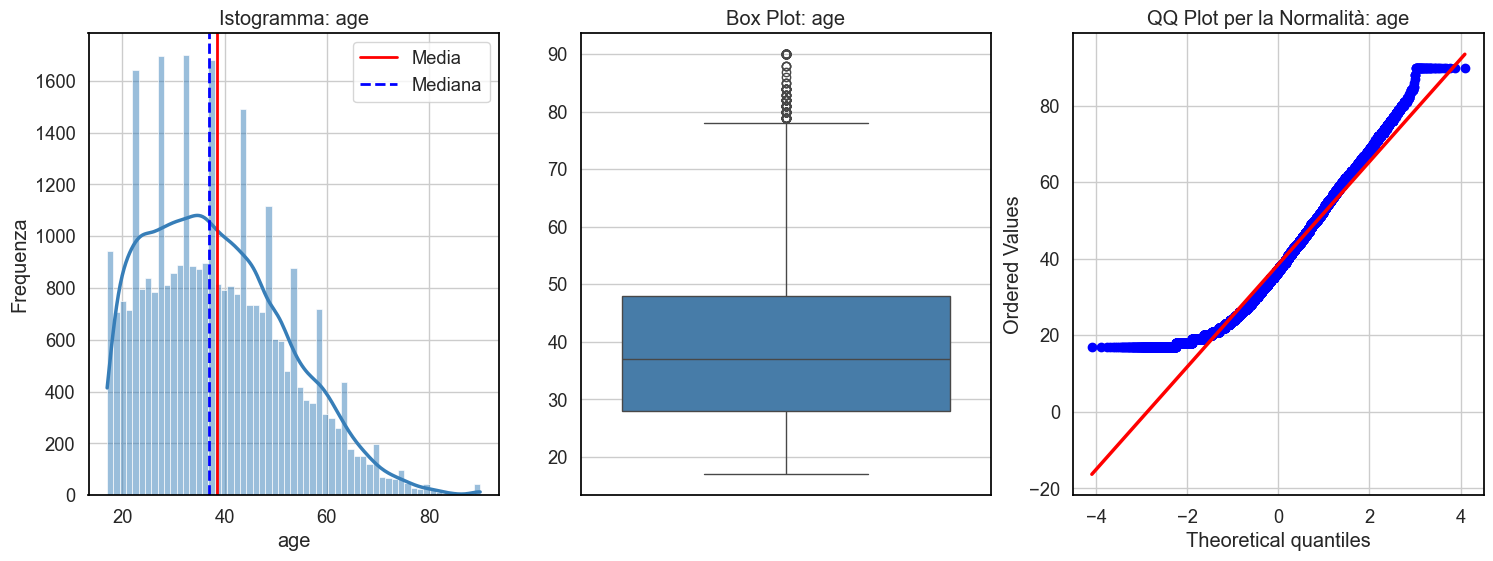

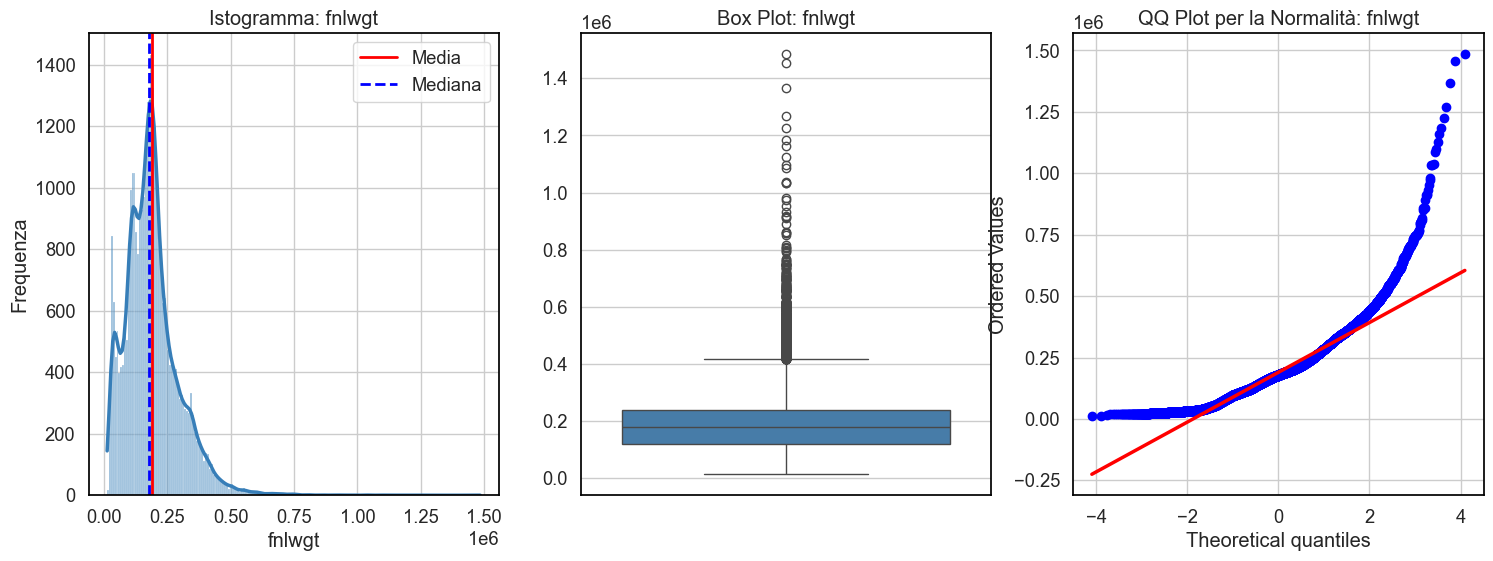

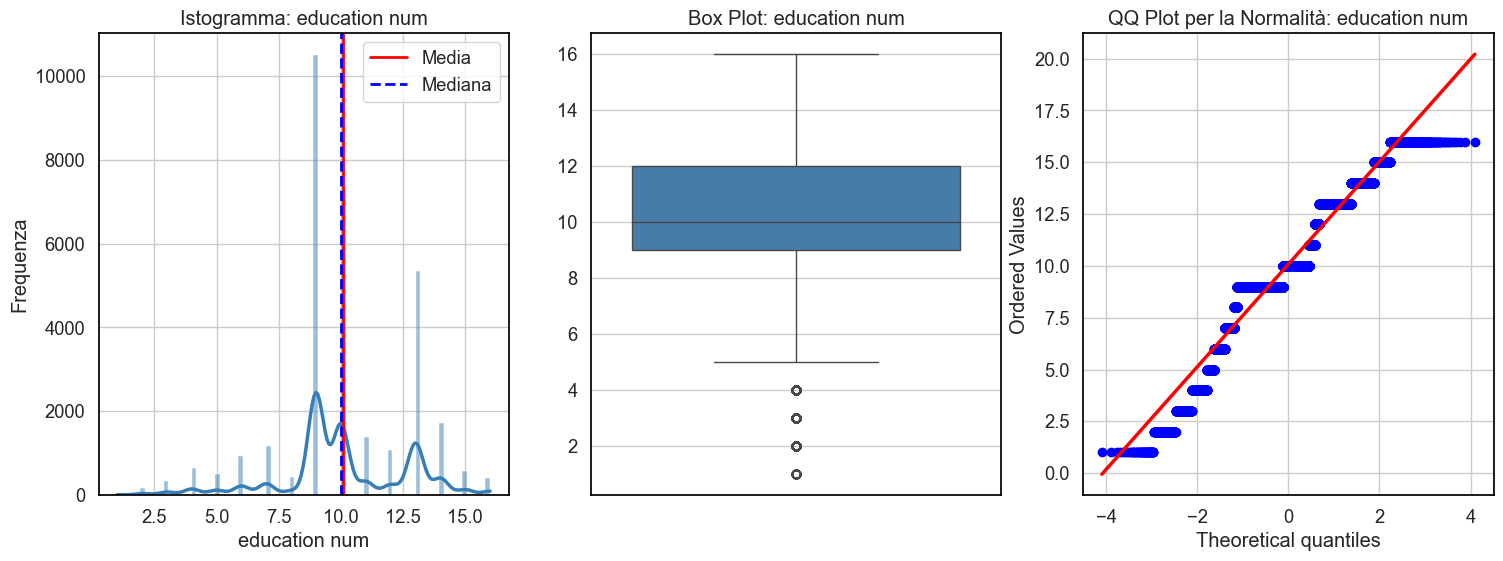

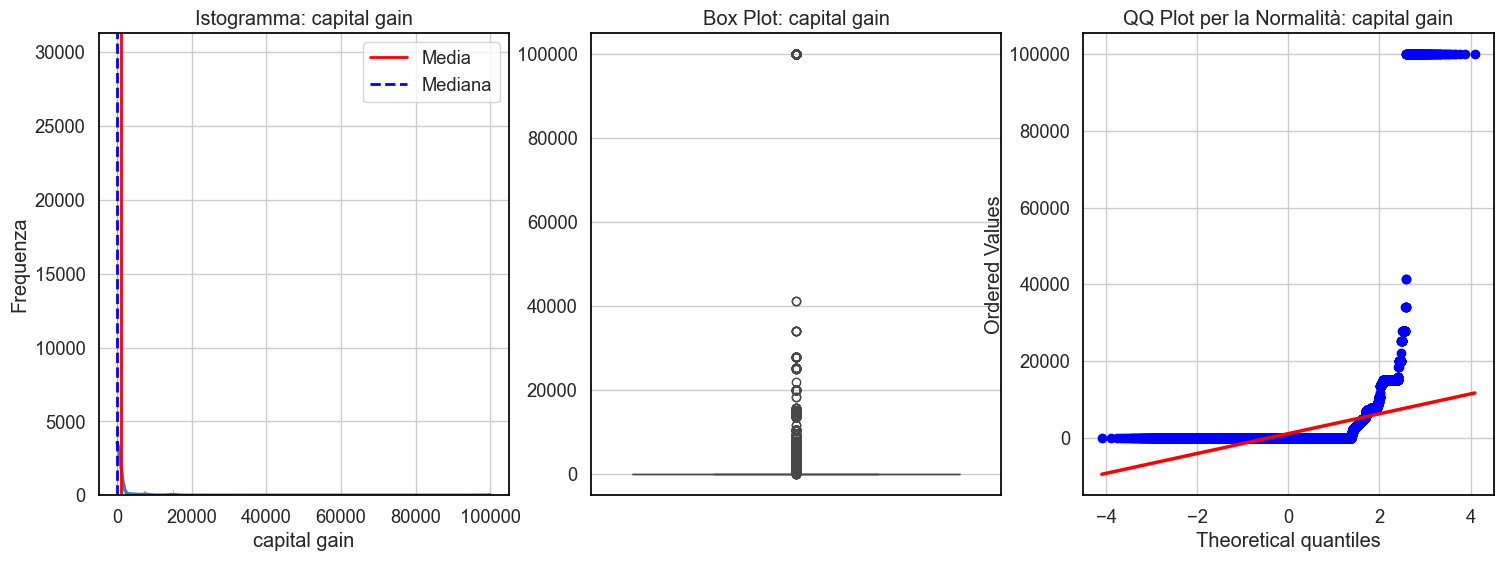

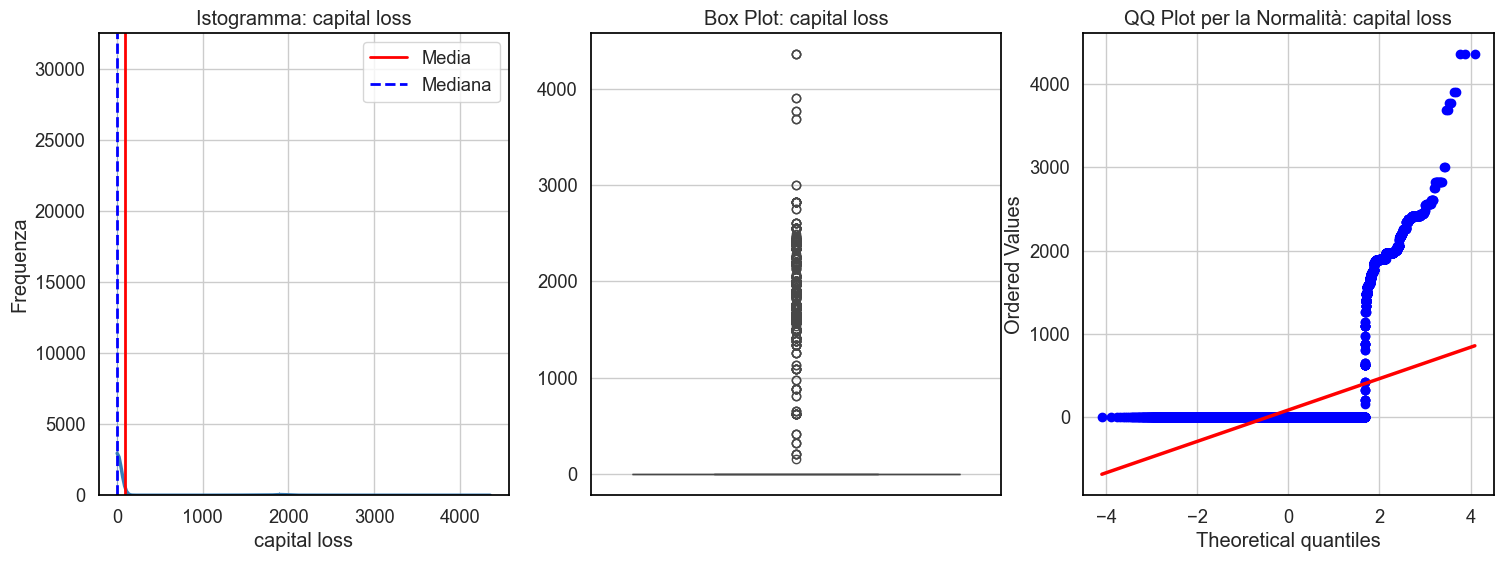

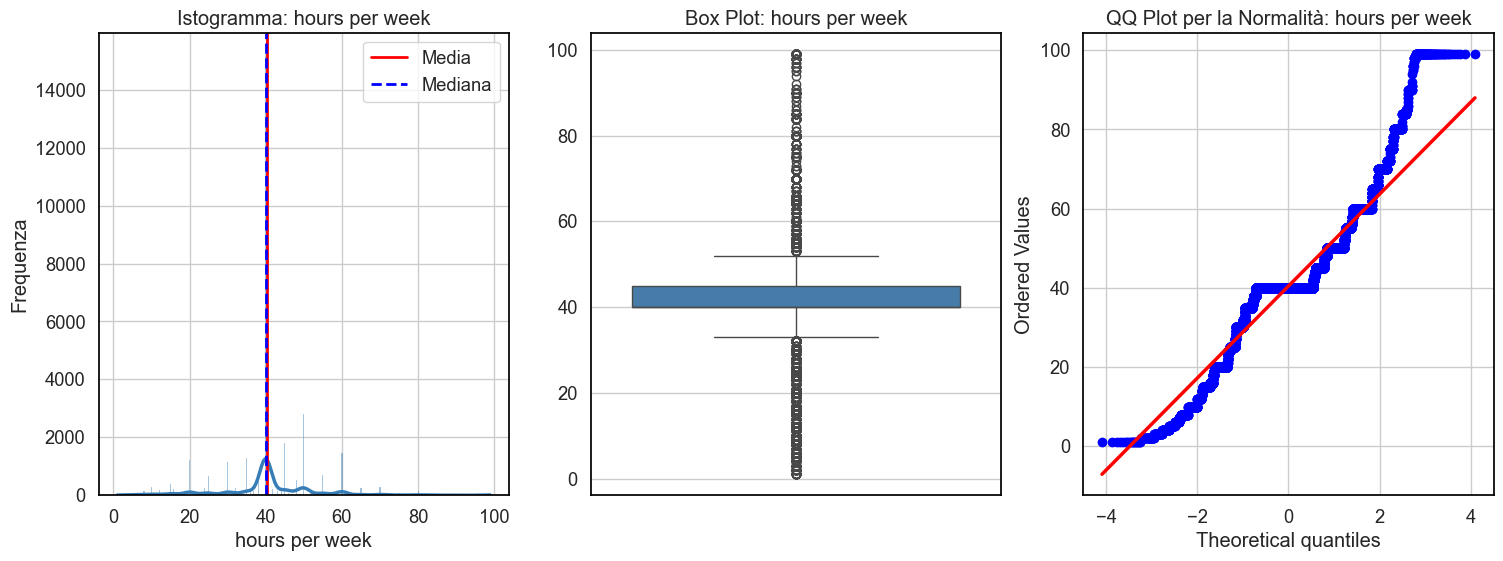

In [ ]:
for col in numerical_cols:

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    sns.histplot(df[col], kde=True)
    plt.axvline(x=df[col].mean(), color='red', linestyle='-', linewidth=2, label='Media')
    plt.axvline(x=df[col].median(), color='blue', linestyle='--', linewidth=2, label='Mediana')

    plt.title(f'Istogramma: {col}')
    plt.xlabel(col)
    plt.ylabel('Frequenza')
    plt.legend()

    plt.subplot(1, 3, 2)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot: {col}')
    plt.ylabel('')

    plt.subplot(1, 3, 3)
    stats.probplot(df[col], dist="norm", plot=plt)
    plt.title(f'QQ Plot per la Normalità: {col}')
    plt.show()

    plt.show()

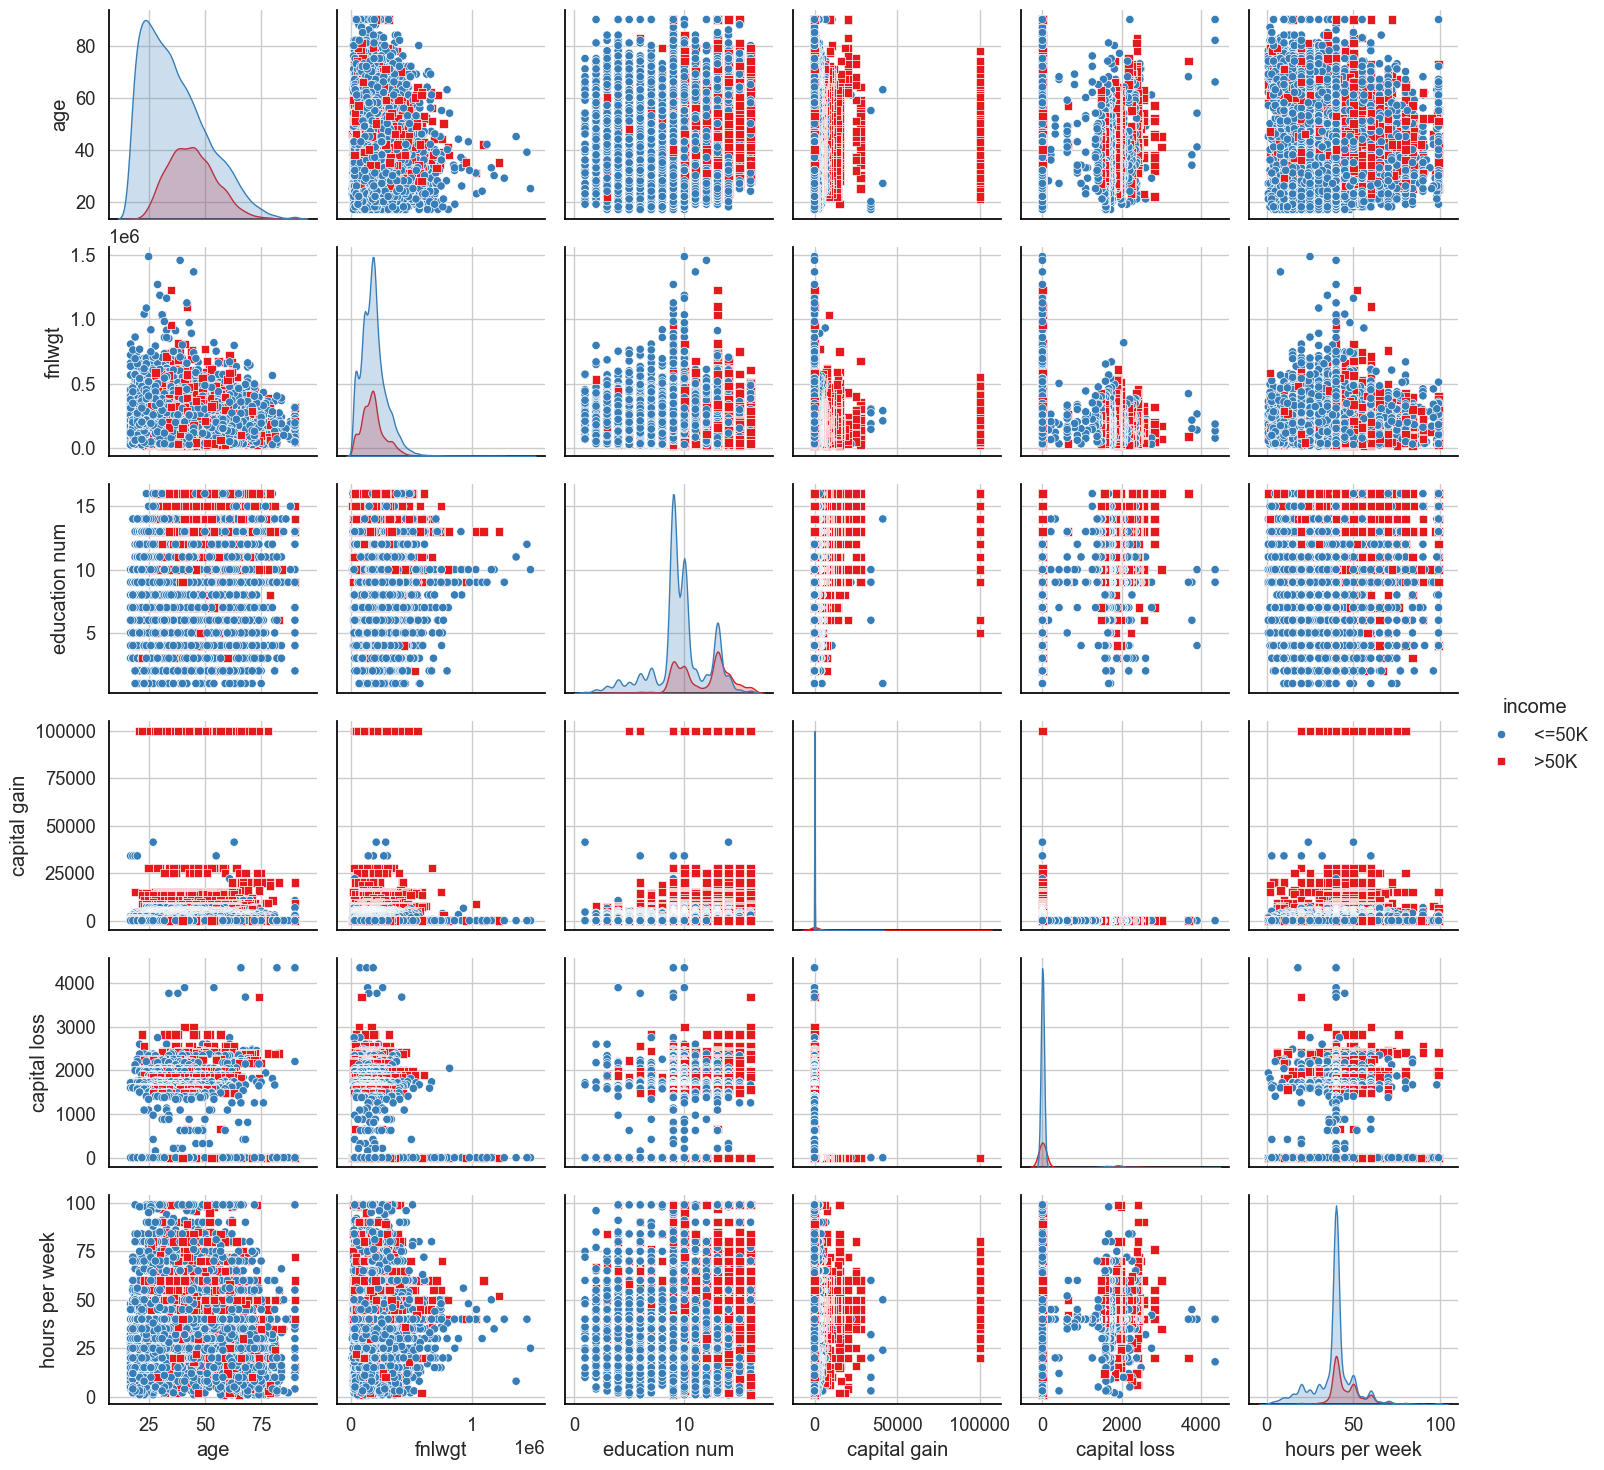

In [ ]:
sns.pairplot(df, hue='income', diag_kind='kde', markers=['o', 's'])

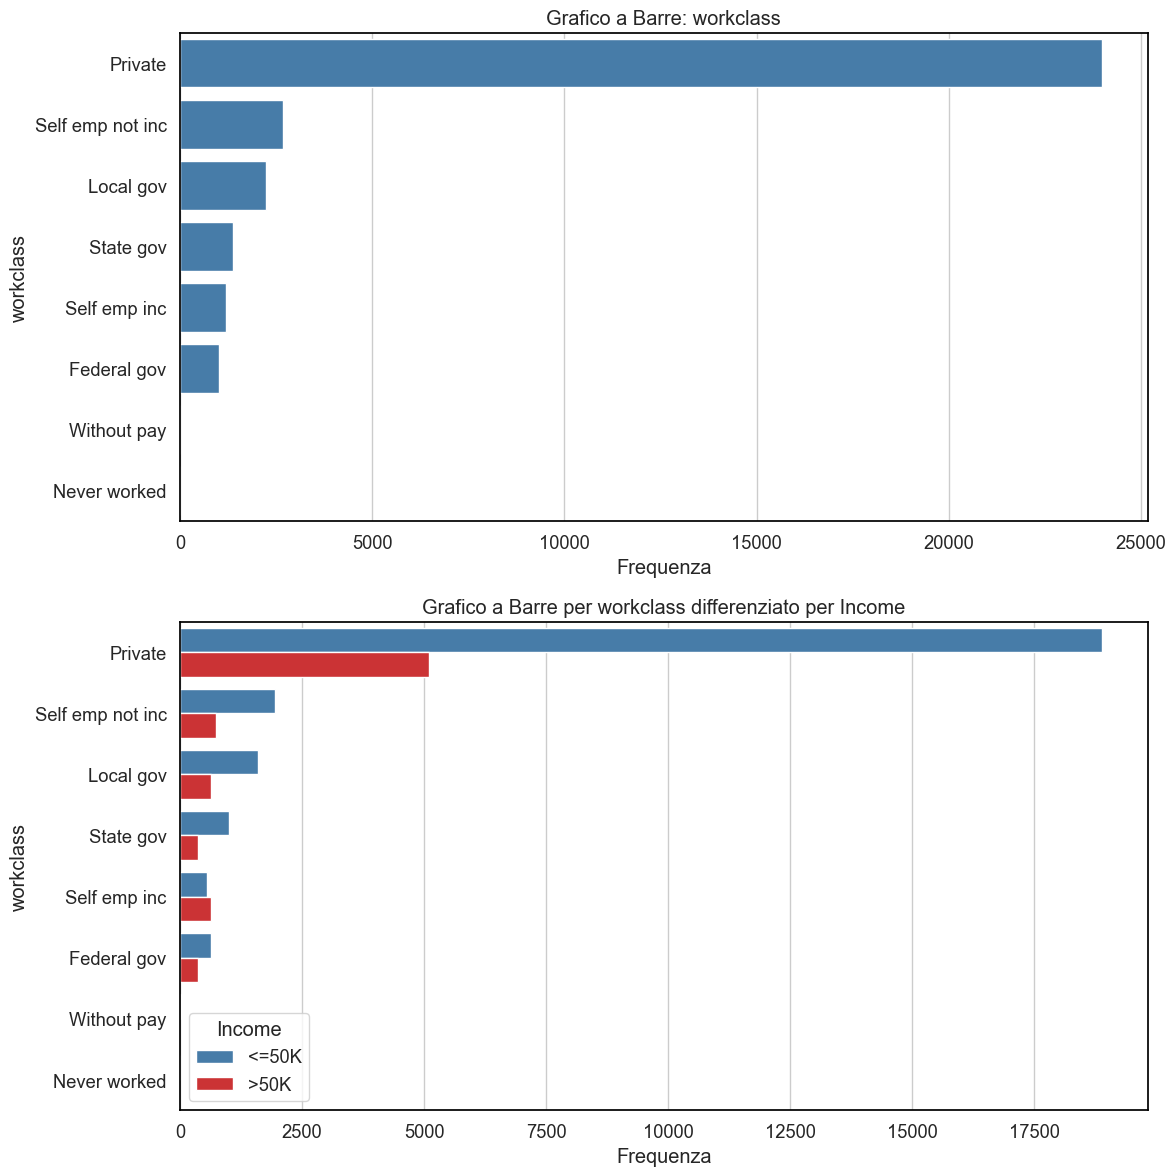

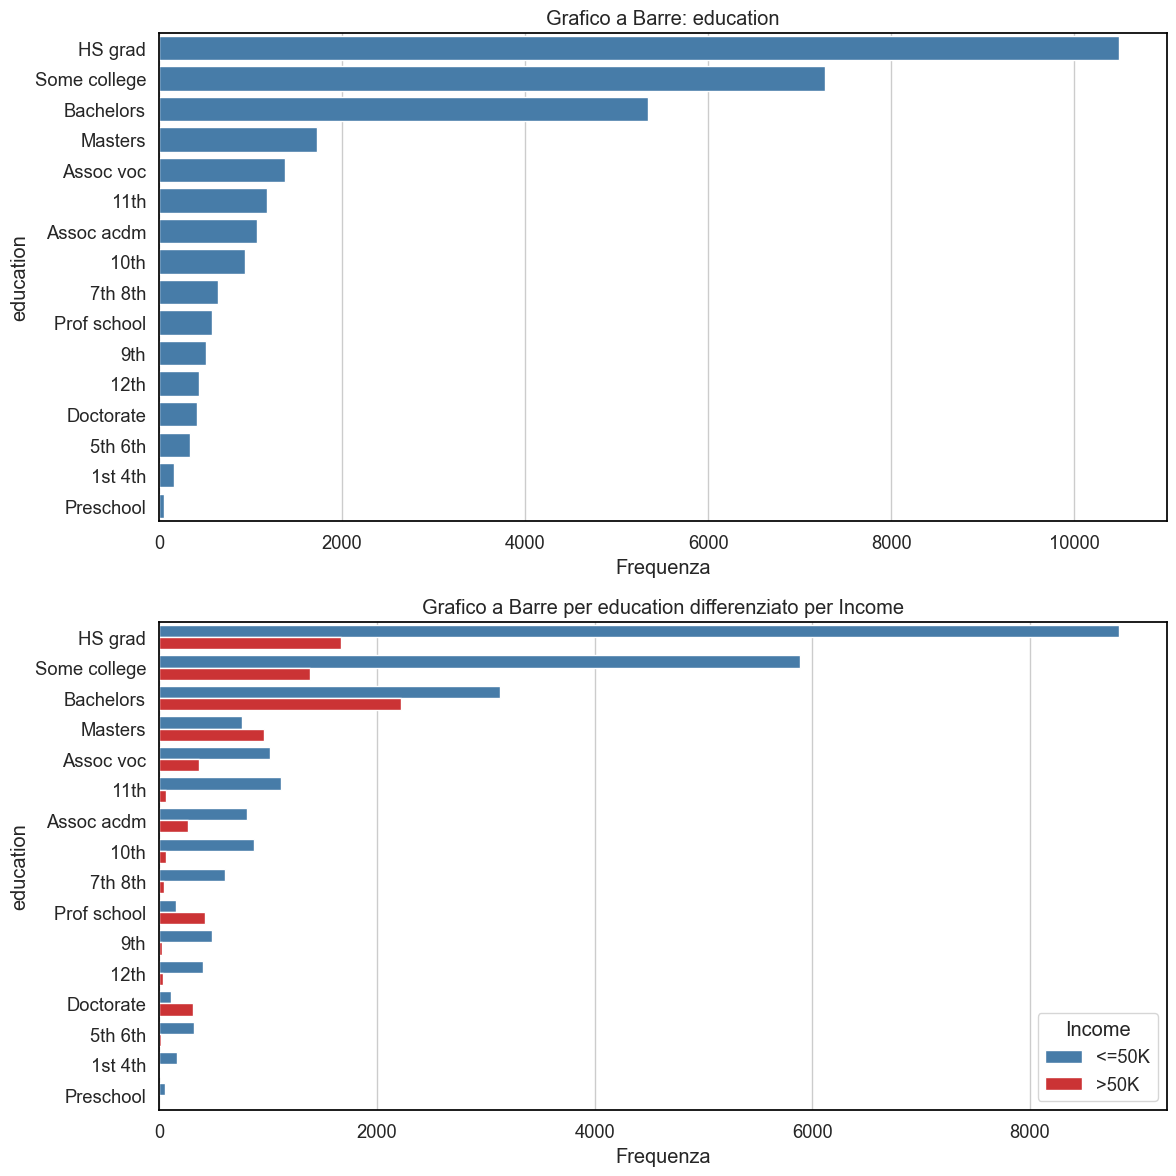

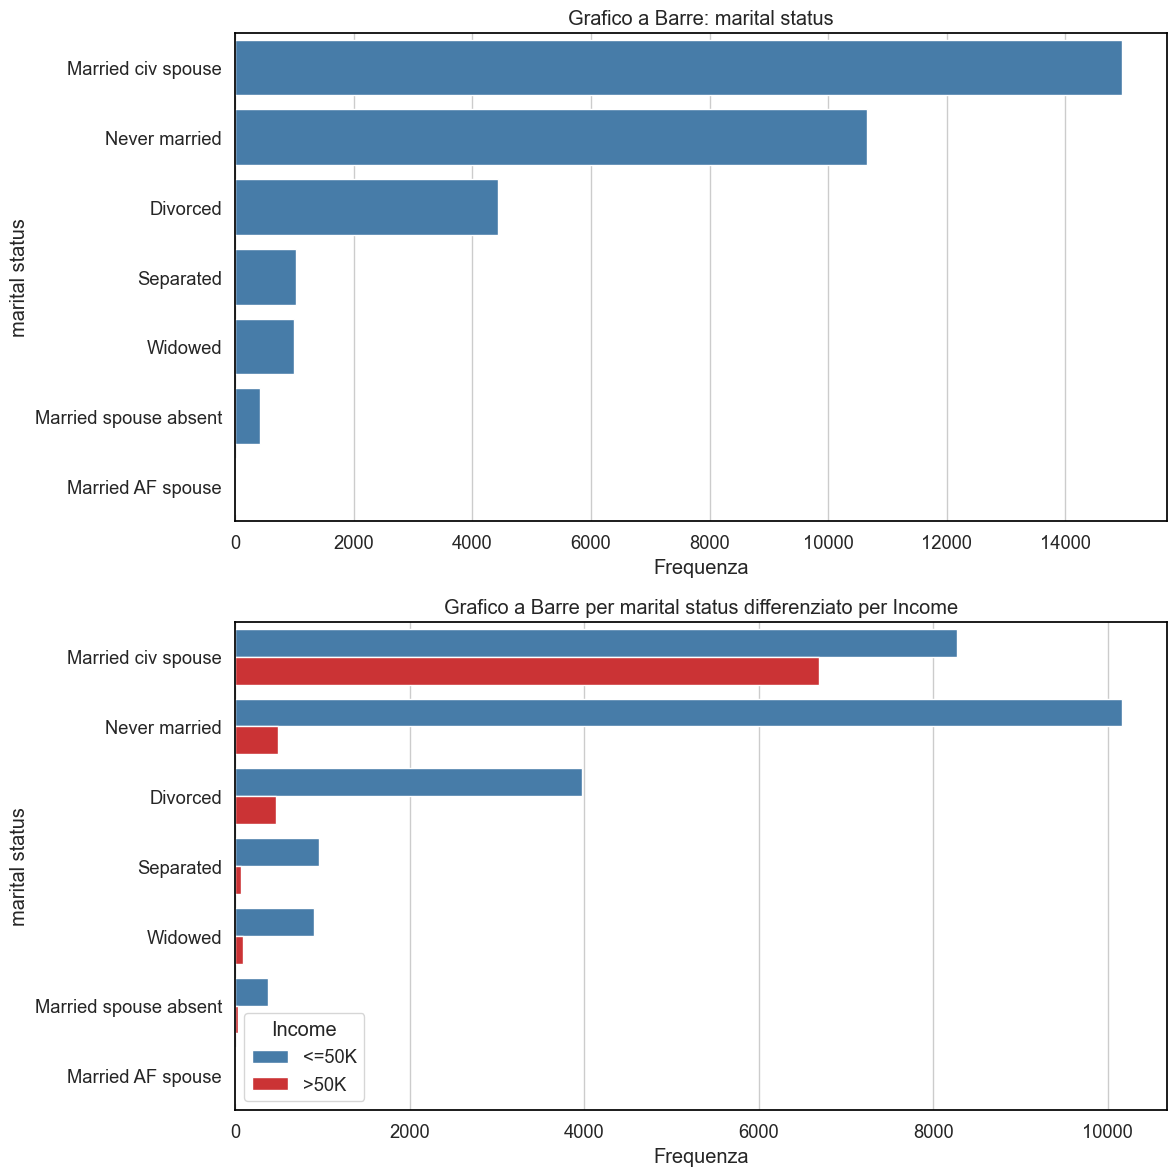

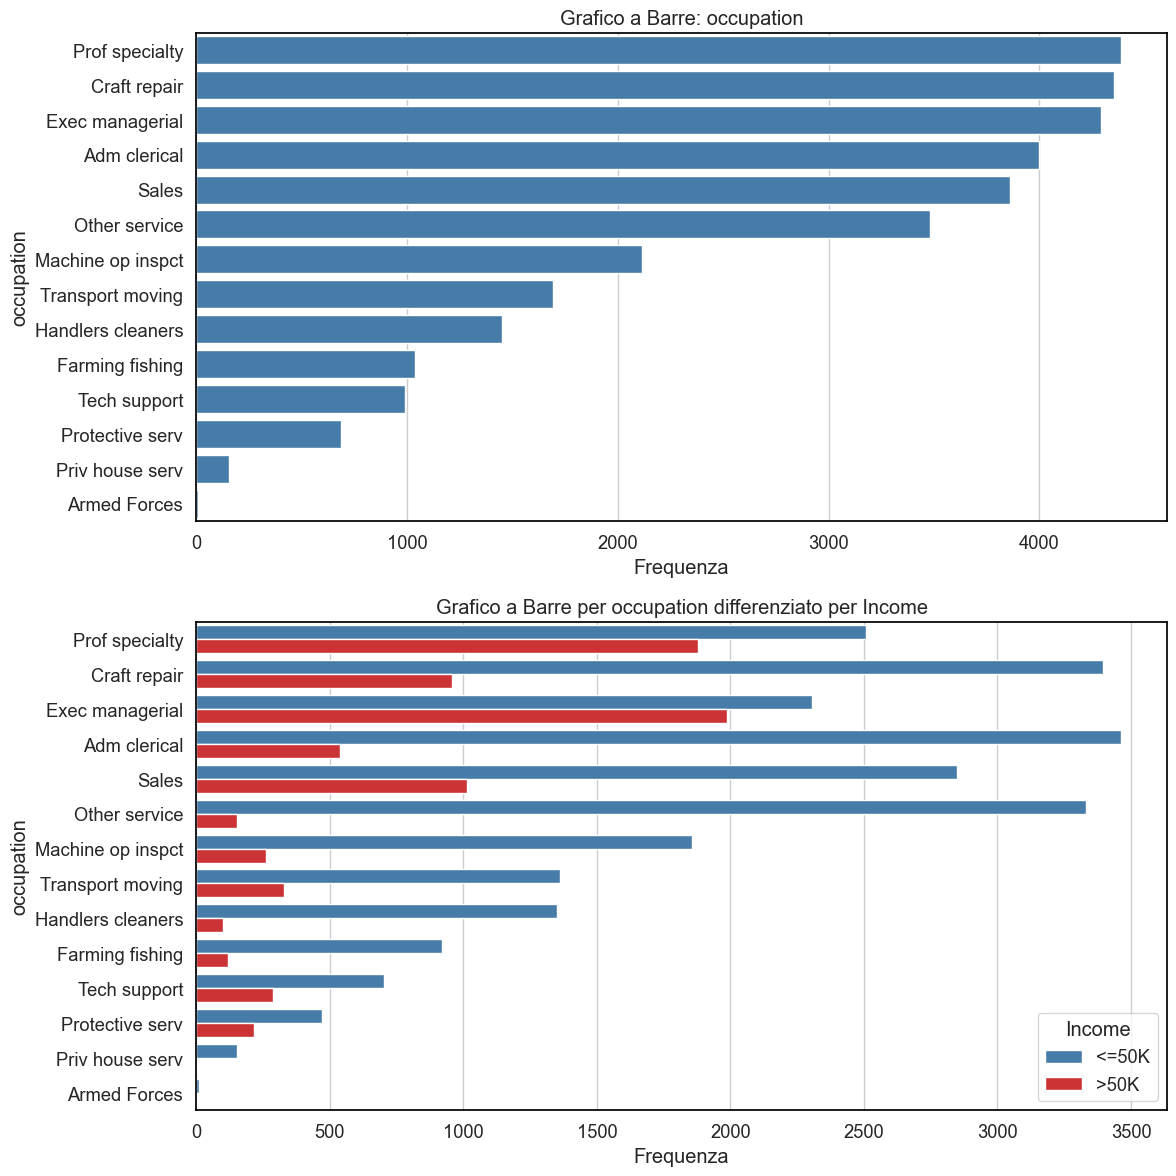

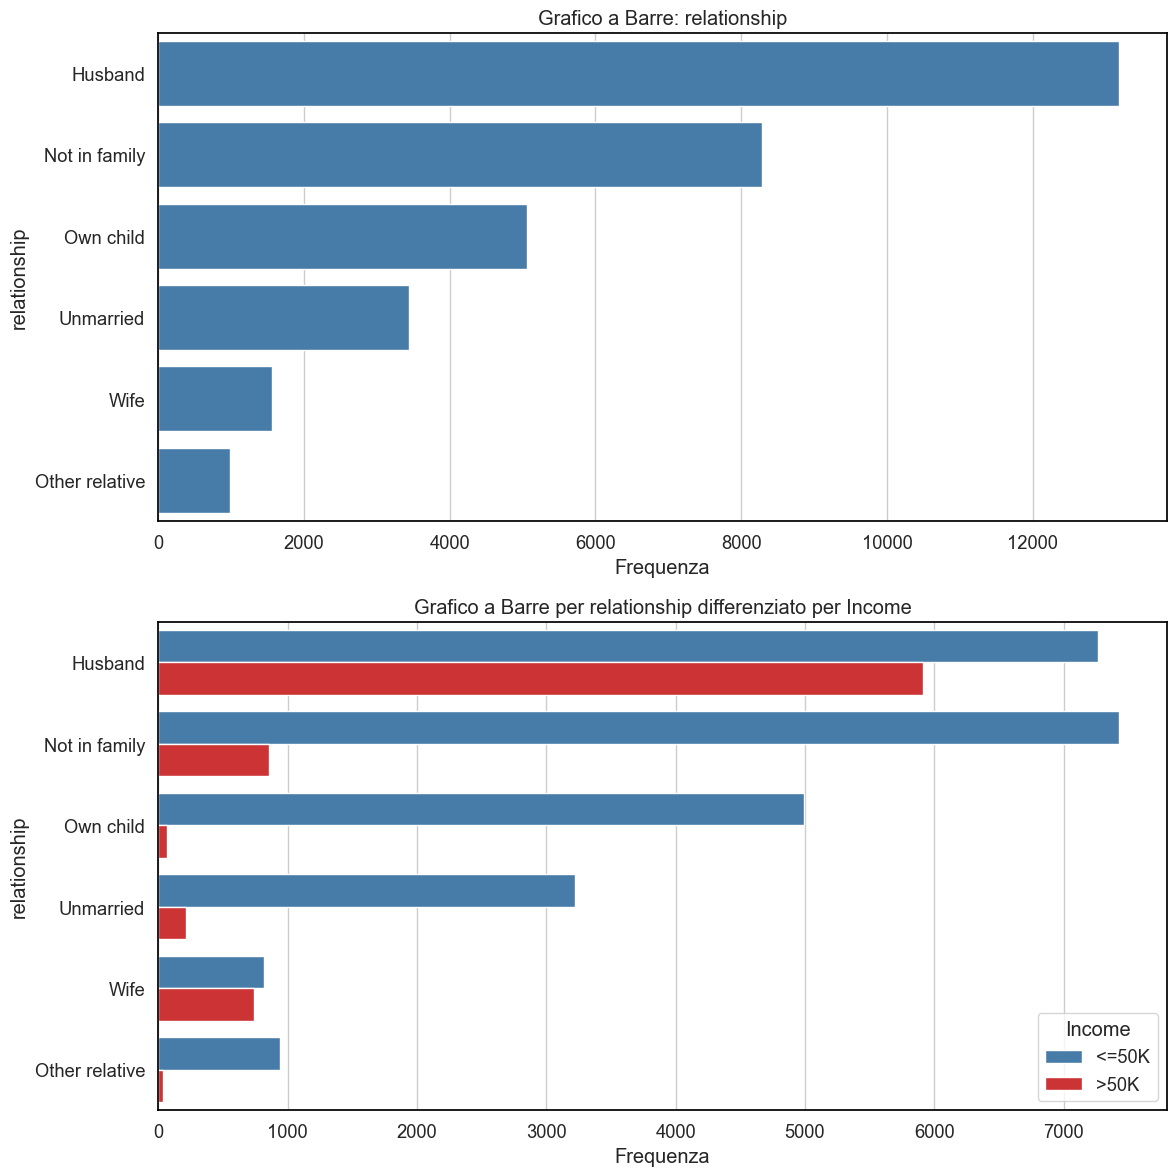

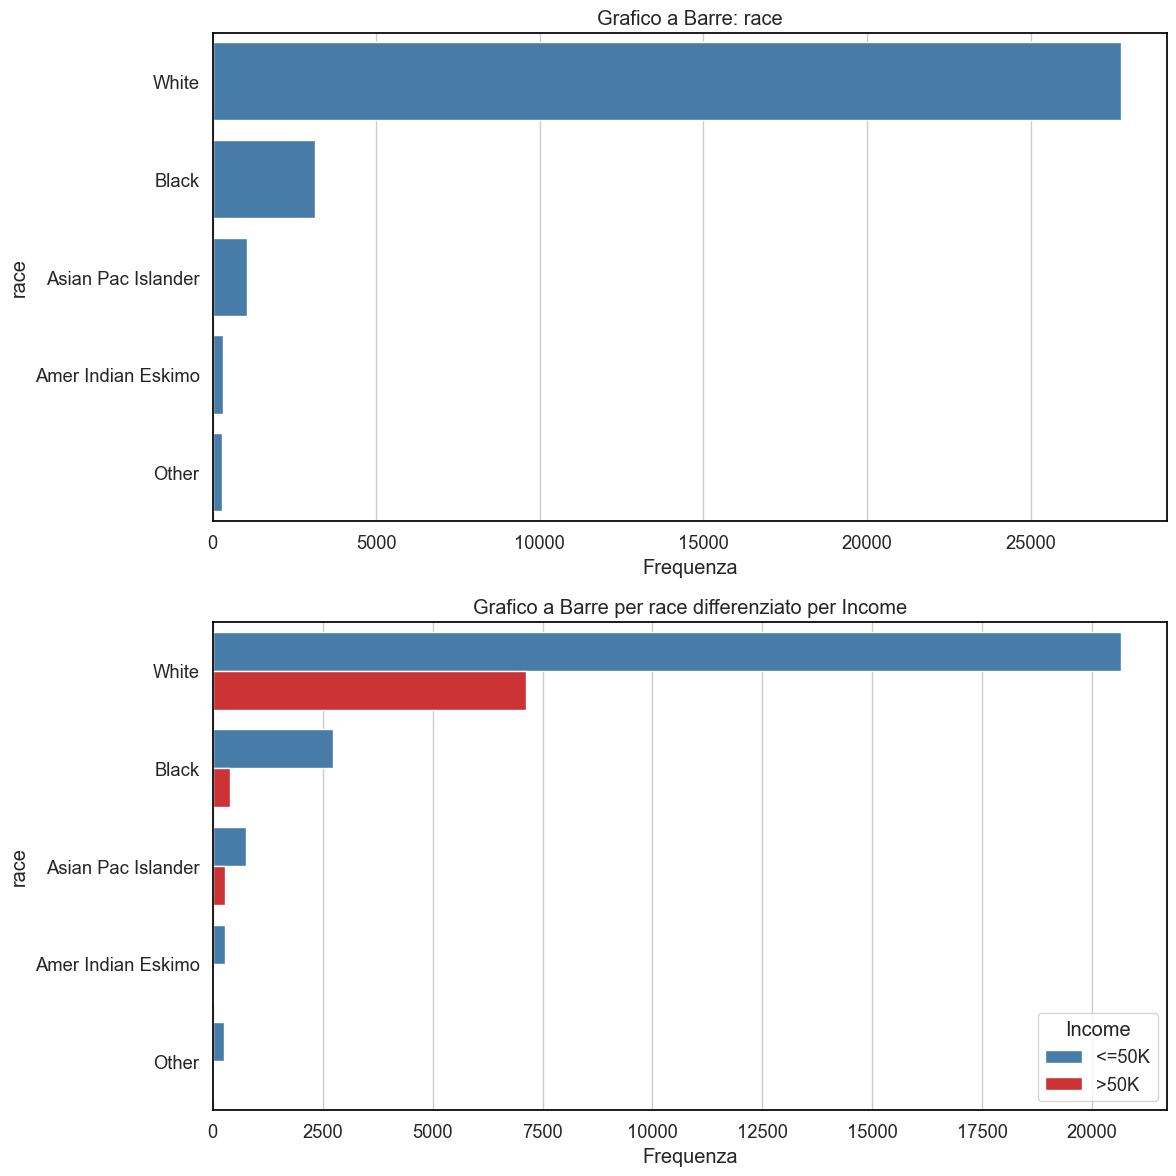

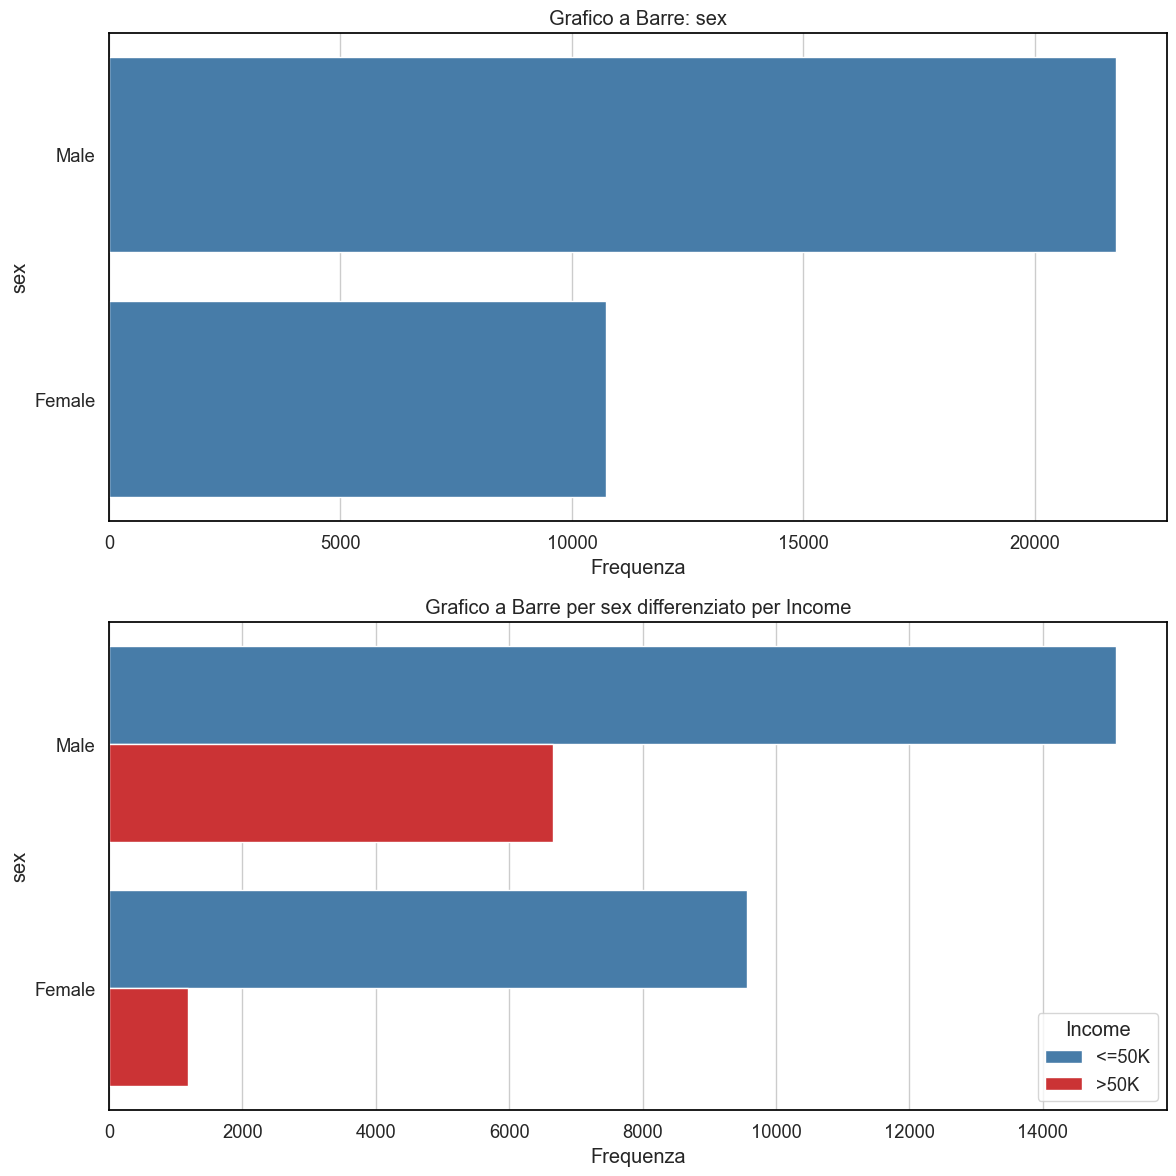

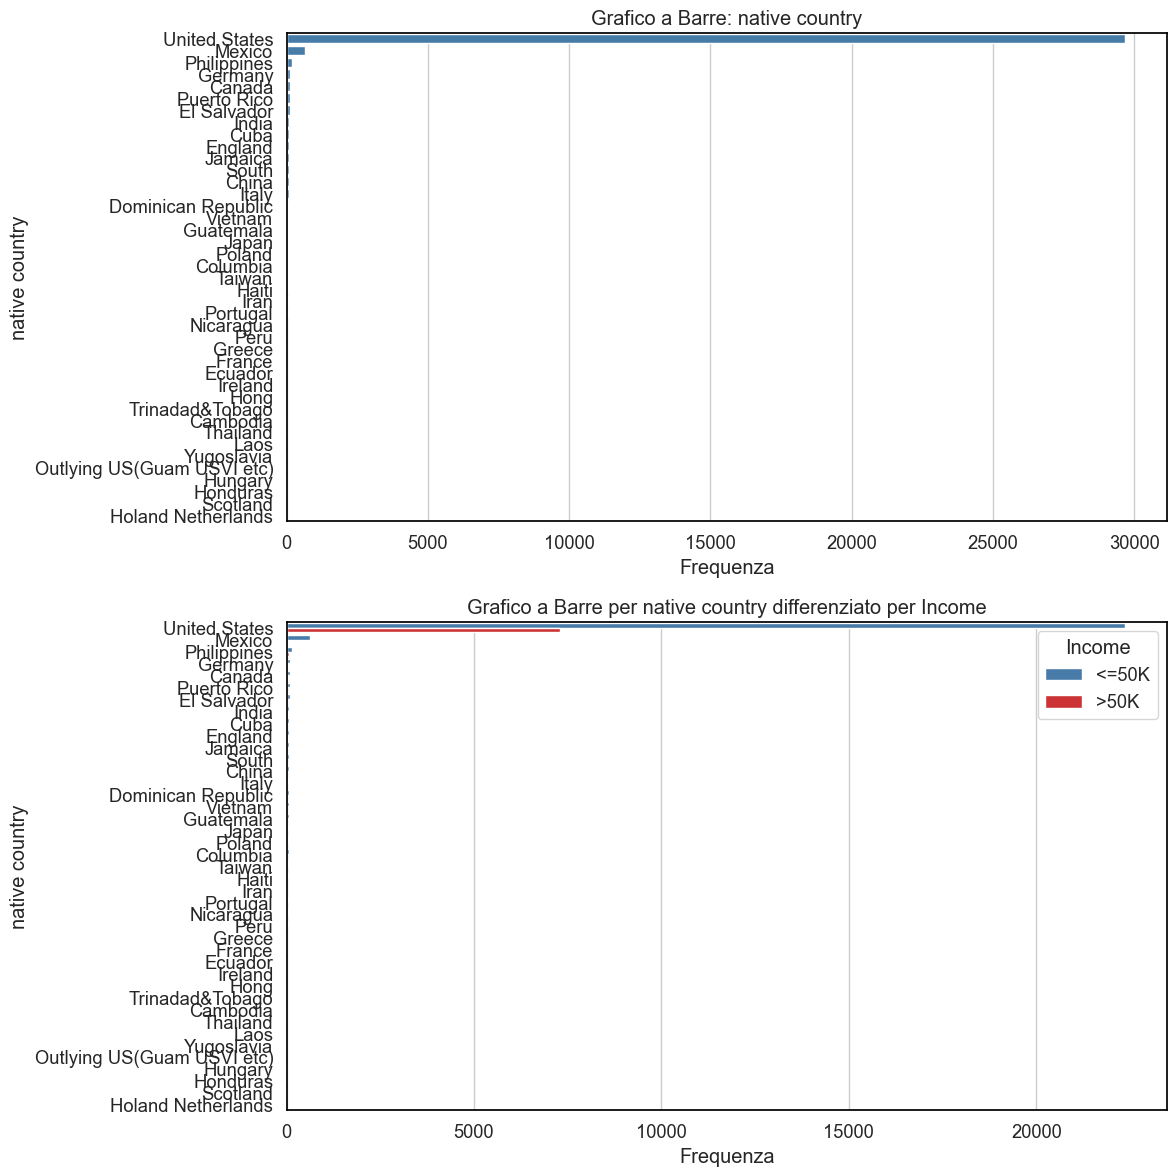

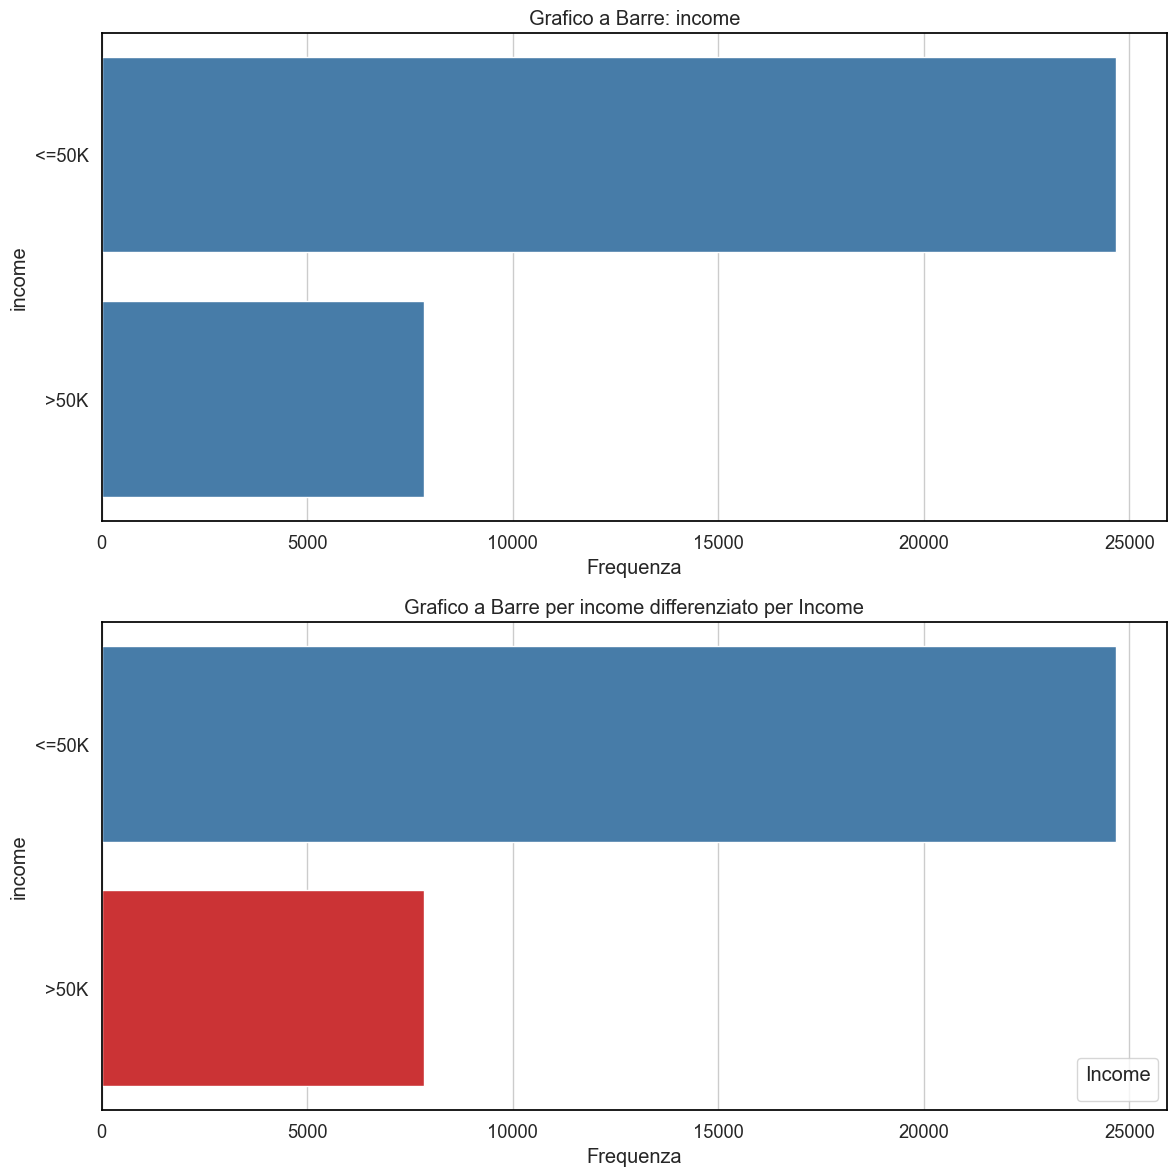

In [ ]:
for col in categorical_cols:
    plt.figure(figsize=(12, 12))

    plt.subplot(2, 1, 1)
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f'Grafico a Barre: {col}')
    plt.xlabel('Frequenza')
    plt.ylabel(col)

    plt.subplot(2, 1, 2)
    sns.countplot(y=df[col], hue=df['income'], order=df[col].value_counts().index)
    plt.title(f'Grafico a Barre per {col} differenziato per Income')
    plt.xlabel('Frequenza')
    plt.ylabel(col)
    plt.legend(title='Income')

    plt.tight_layout()
    plt.show()


In [ ]:
for col in categorical_cols:
    print(f"\n### {col}\n")

    # Crea dataframe riassuntivo
    summary_data = []

    for val in df[col].value_counts().index:
        total = (df[col] == val).sum()
        low_income = ((df[col] == val) & (df['income'] == '<=50K')).sum()
        high_income = ((df[col] == val) & (df['income'] == '>50K')).sum()

        pct_total = (total / len(df)) * 100
        pct_low = (low_income / total) * 100 if total > 0 else 0
        pct_high = (high_income / total) * 100 if total > 0 else 0

        summary_data.append({
            'Categoria': val,
            'Totale': total,
            '% sul totale': f"{pct_total:.1f}%",
            '<=50K': low_income,
            '<=50K %': f"{pct_low:.1f}%",
            '>50K': high_income,
            '>50K %': f"{pct_high:.1f}%"
        })

    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))

    print("\n" + "="*100 + "\n")



### workclass

       Categoria  Totale % sul totale  <=50K <=50K %  >50K >50K %
         Private   23971        73.7%  18875   78.7%  5096  21.3%
Self emp not inc    2691         8.3%   1957   72.7%   734  27.3%
       Local gov    2237         6.9%   1605   71.7%   632  28.3%
       State gov    1379         4.2%   1016   73.7%   363  26.3%
    Self emp inc    1191         3.7%    560   47.0%   631  53.0%
     Federal gov    1020         3.1%    641   62.8%   379  37.2%
     Without pay      14         0.0%     14  100.0%     0   0.0%
    Never worked       7         0.0%      7  100.0%     0   0.0%



### education

   Categoria  Totale % sul totale  <=50K <=50K %  >50K >50K %
     HS grad   10489        32.3%   8816   84.0%  1673  16.0%
Some college    7275        22.4%   5890   81.0%  1385  19.0%
   Bachelors    5346        16.4%   3127   58.5%  2219  41.5%
     Masters    1721         5.3%    762   44.3%   959  55.7%
   Assoc voc    1380         4.2%   1019   73.8%   361  26.2%


L’analisi delle variabili categoriche del dataset *Adult Census Income* evidenzia pattern chiari nella distribuzione del reddito.
Il livello di **istruzione** è il fattore più incisivo: chi possiede titoli avanzati (Doctorate, Prof-school, Masters) supera spesso i 50K, mentre chi ha bassa scolarità raramente lo fa. Anche l’**occupazione** incide fortemente: ruoli manageriali e professionali, insieme all’imprenditorialità (*Self-emp-inc*), mostrano le percentuali di reddito alto più elevate, a differenza dei lavori manuali o di servizio.
Si rilevano **disparità di genere** marcate (30.6% uomini vs 11% donne sopra i 50K) e differenze etniche, con White e Asian-Pac-Islander più rappresentati nella fascia alta di reddito. Lo **stato civile** risulta anch’esso determinante: i coniugati (“Married-civ-spouse”) hanno redditi più elevati, mentre i “Never-married” restano nettamente indietro.
Dal punto di vista **geografico**, la maggior parte del campione proviene dagli USA, ma alcuni Paesi esteri (India, Iran, Taiwan, Francia) mostrano percentuali di reddito alto superiori alla media americana.

<Figure size 2500x1800 with 0 Axes>

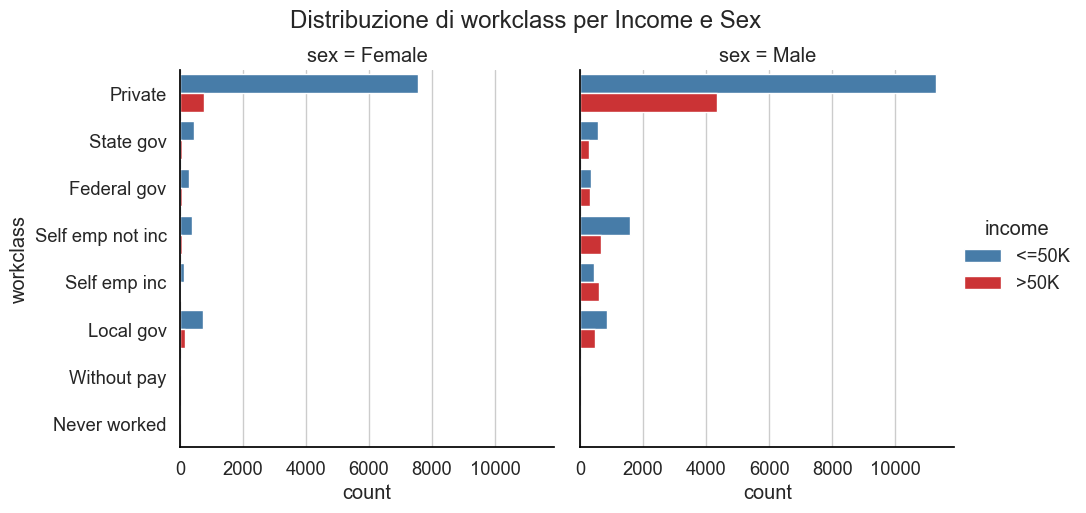

<Figure size 2500x1800 with 0 Axes>

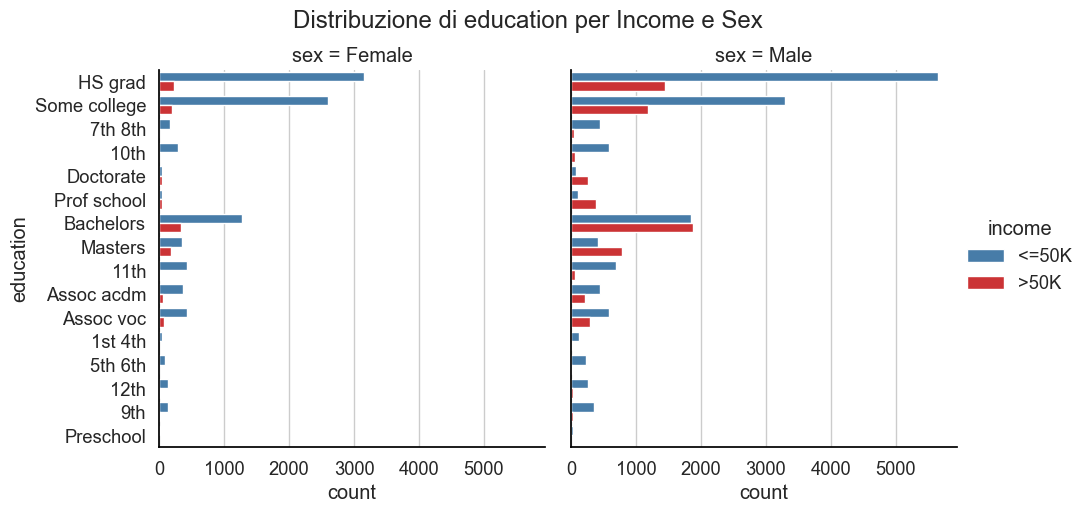

<Figure size 2500x1800 with 0 Axes>

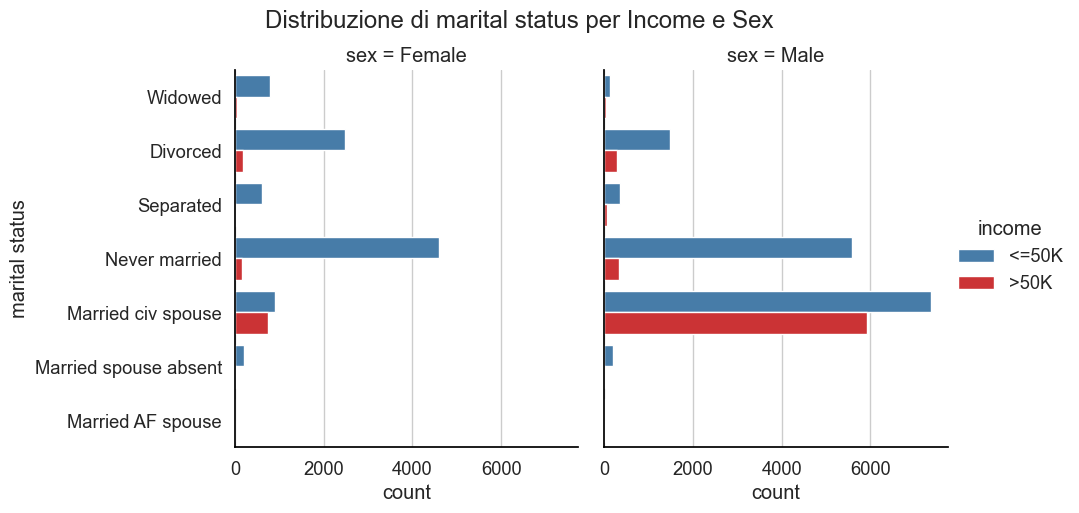

<Figure size 2500x1800 with 0 Axes>

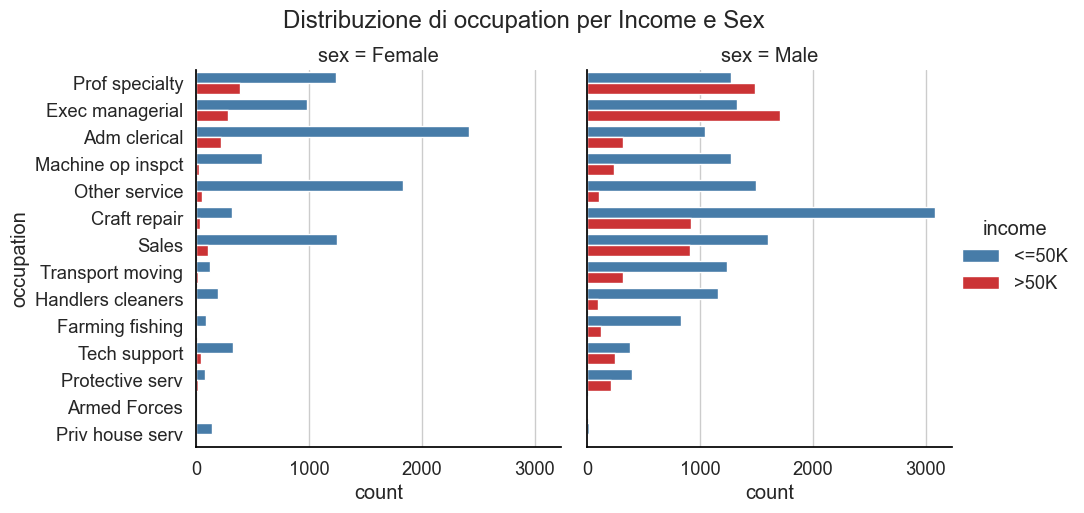

<Figure size 2500x1800 with 0 Axes>

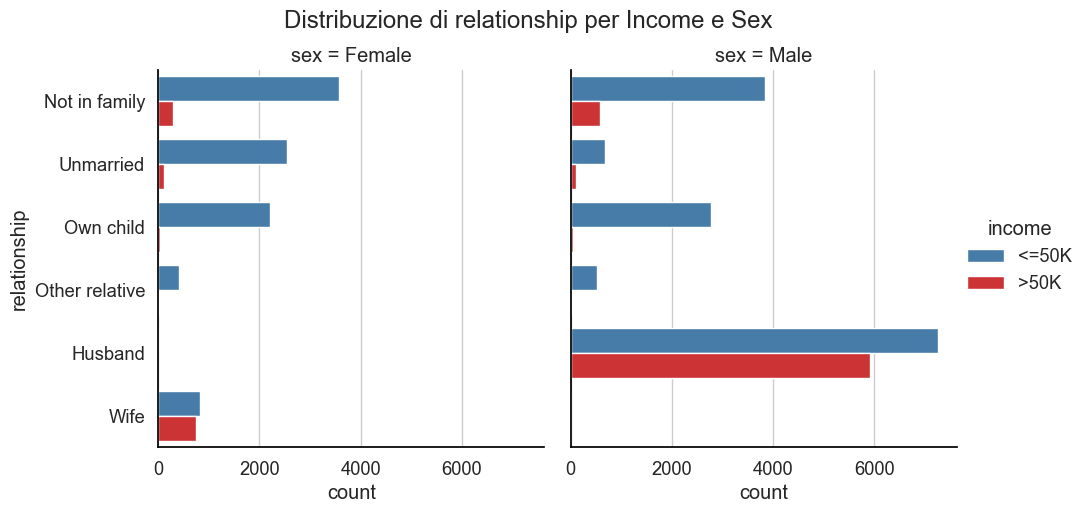

<Figure size 2500x1800 with 0 Axes>

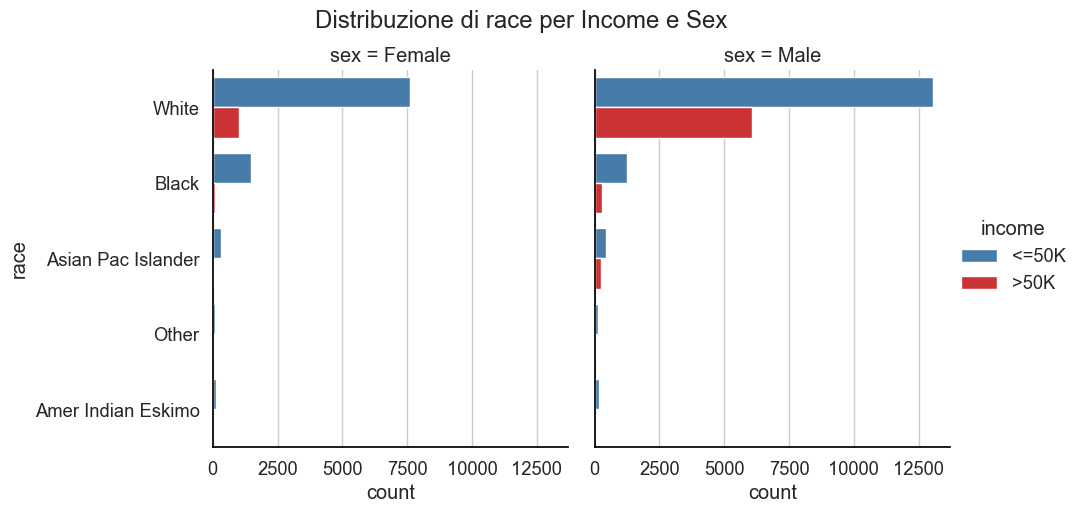

<Figure size 2500x1800 with 0 Axes>

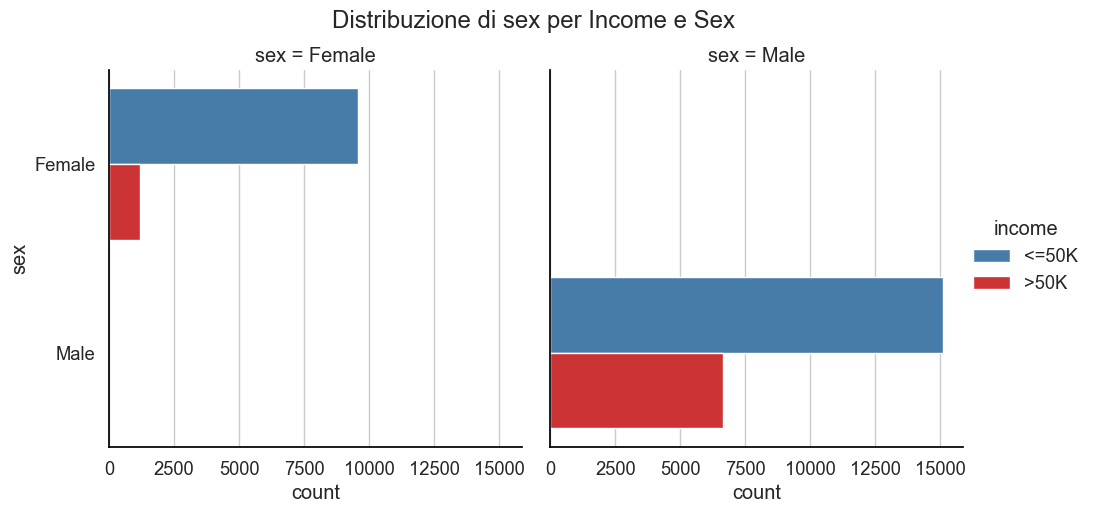

<Figure size 2500x1800 with 0 Axes>

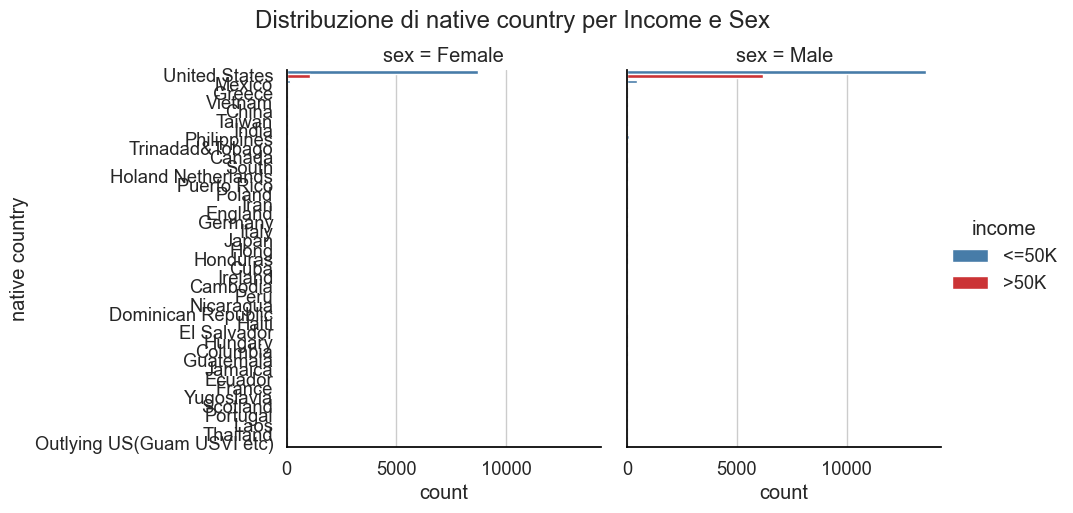

<Figure size 2500x1800 with 0 Axes>

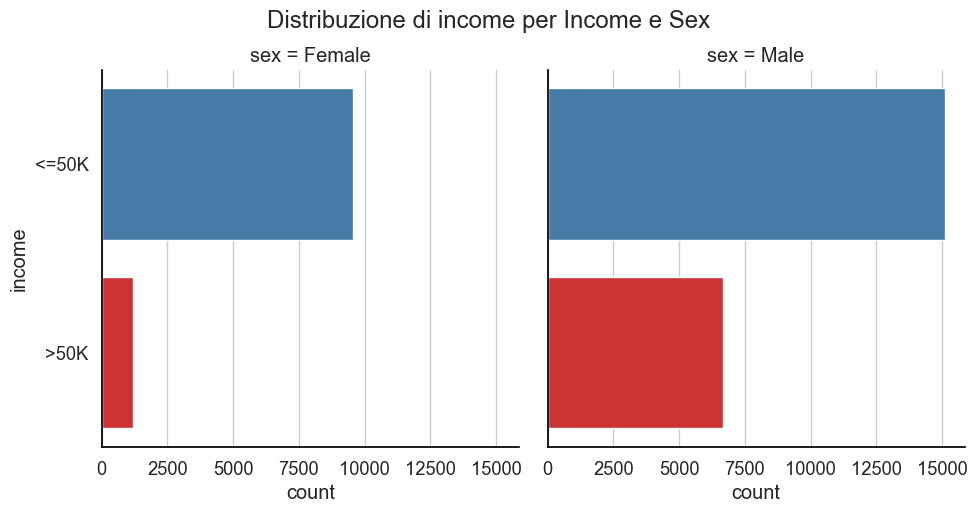

In [ ]:
for coll in categorical_cols:
    plt.figure(figsize=(25, 18))
    sns.catplot(y=coll, hue="income", kind="count", col='sex', data=df)
    plt.suptitle(f'Distribuzione di {coll} per Income e Sex', y=1.03)
    plt.show()

In [ ]:
for coll in categorical_cols:
    # Salta se la colonna è sex o income
    if coll in ['sex', 'income']:
        continue

    print(f"\n## {coll.upper()}\n")

    # Raggruppa e conta
    summary = df.groupby(['sex', 'income', coll]).size().reset_index(name='count')

    # Calcola percentuali per gruppo
    summary['total_group'] = summary.groupby(['sex', 'income'])['count'].transform('sum')
    summary['percentage'] = (summary['count'] / summary['total_group'] * 100).round(1)

    # Ordina per rendere più leggibile
    summary = summary.sort_values(['sex', 'income', 'count'], ascending=[True, True, False])

    # Stampa in formato tabellare
    print(summary.to_string(index=False))
    print("\n" + "="*80)



## WORKCLASS

   sex income        workclass  count  total_group  percentage
Female  <=50K          Private   7570         9570        79.1
Female  <=50K        Local gov    744         9570         7.8
Female  <=50K        State gov    456         9570         4.8
Female  <=50K Self emp not inc    387         9570         4.0
Female  <=50K      Federal gov    283         9570         3.0
Female  <=50K     Self emp inc    123         9570         1.3
Female  <=50K      Without pay      5         9570         0.1
Female  <=50K     Never worked      2         9570         0.0
Female   >50K          Private    766         1177        65.1
Female   >50K        Local gov    157         1177        13.3
Female   >50K Self emp not inc     83         1177         7.1
Female   >50K        State gov     72         1177         6.1
Female   >50K      Federal gov     57         1177         4.8
Female   >50K     Self emp inc     42         1177         3.6
  Male  <=50K          Private  11305   

### Osservazioni
L’analisi bivariata mostra forti disparità di genere nel reddito: le donne rappresentano solo il 15.5% del segmento ad alto reddito, pur essendo un terzo del campione.
Si evidenzia segregazione occupazionale, con le donne concentrate in ruoli amministrativi e di servizio e gli uomini in lavori tecnici e manuali. Tra i redditi alti, entrambi i sessi occupano ruoli manageriali, ma le donne restano più presenti in posizioni di supporto.
Lo stato civile incide diversamente: la maggior parte degli uomini ricchi è sposata, mentre le donne non sposate risultano più numerose tra i redditi alti.
Infine, l’istruzione avanzata è più comune tra le donne ad alto reddito, ma non basta a colmare il divario economico di genere.

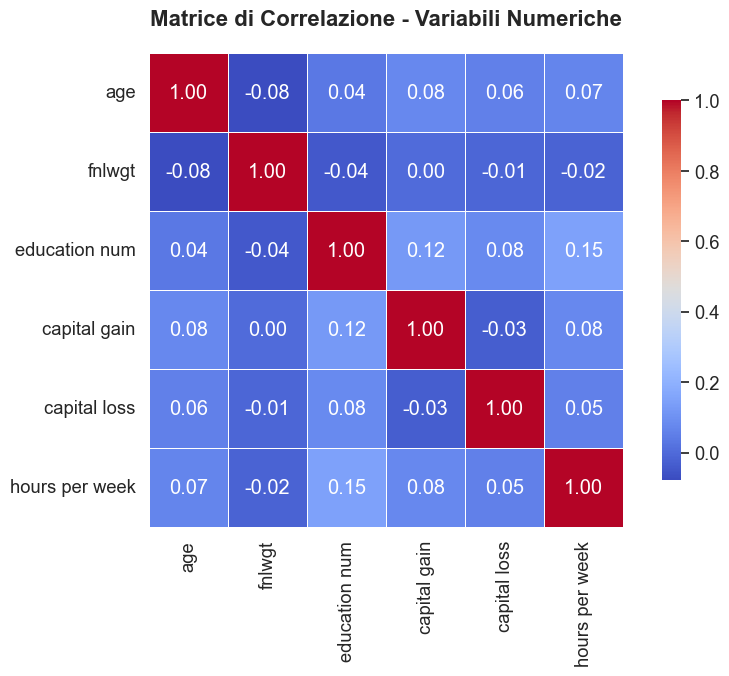


Correlazioni Forti (|r| > 0.5):



In [ ]:
matrice = df[numerical_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(matrice, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matrice di Correlazione - Variabili Numeriche', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nCorrelazioni Forti (|r| > 0.5):\n")
for i in range(len(matrice.columns)):
    for j in range(i+1, len(matrice.columns)):
        if abs(matrice.iloc[i, j]) > 0.5:
            print(f"{matrice.columns[i]:20s} <-> {matrice.columns[j]:20s}: {matrice.iloc[i, j]:.3f}")

### Osservazioni
La matrice di correlazione non mostra nessuna relazione significativa (|r| > 0.5)

---

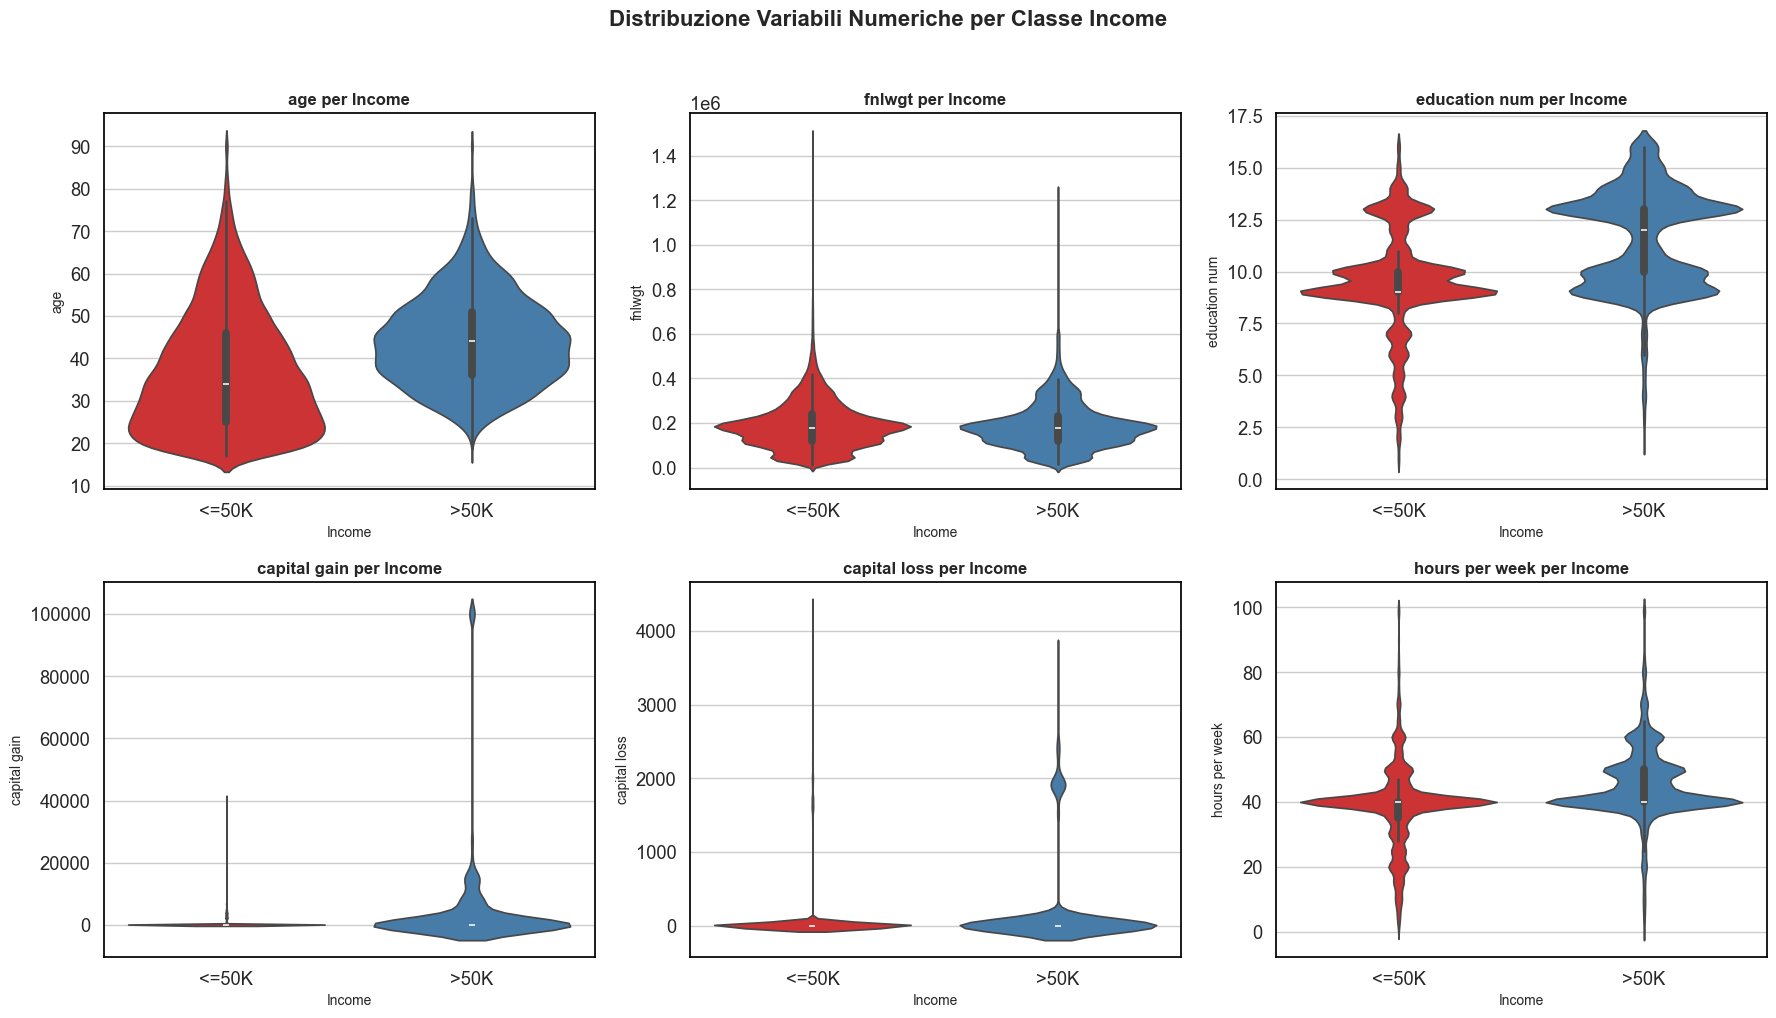

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    if idx < len(axes):
        sns.violinplot(x='income', y=df[col], data=df, ax=axes[idx], palette='Set1')
        axes[idx].set_title(f'{col} per Income', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Income', fontsize=10)
        axes[idx].set_ylabel(col, fontsize=10)

plt.suptitle('Distribuzione Variabili Numeriche per Classe Income',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
for col in numerical_cols:
    print(f"\n## {col.upper()}\n")

    # Statistiche descrittive per gruppo income
    stats = df.groupby('income')[col].describe().round(2)

    print("STATISTICHE DESCRITTIVE PER INCOME:")
    print(stats)
    print("\n")

    # Aggiungi mediana e IQR
    additional_stats = df.groupby('income')[col].agg([
        ('median', 'median'),
        ('IQR', lambda x: x.quantile(0.75) - x.quantile(0.25)),
        ('skewness', lambda x: x.skew())
    ]).round(2)

    print("STATISTICHE AGGIUNTIVE:")
    print(additional_stats)
    print("\n")

    # Analisi testuale comparativa
    print("CONFRONTO TRA GRUPPI:")
    low_income = df[df['income'] == '<=50K'][col]
    high_income = df[df['income'] == '>50K'][col]

    print(f"• <=50K: media={low_income.mean():.2f}, mediana={low_income.median():.2f}, std={low_income.std():.2f}")
    print(f"• >50K: media={high_income.mean():.2f}, mediana={high_income.median():.2f}, std={high_income.std():.2f}")

    diff_mean = high_income.mean() - low_income.mean()
    diff_median = high_income.median() - low_income.median()

    print(f"\nDifferenza assoluta:")
    print(f"  - Media: {diff_mean:+.2f} ({(diff_mean/low_income.mean()*100):+.1f}%)")
    print(f"  - Mediana: {diff_median:+.2f} ({(diff_median/low_income.median()*100):+.1f}%)")

    print("\n" + "="*80)



## AGE

STATISTICHE DESCRITTIVE PER INCOME:
          count   mean    std   min   25%   50%   75%   max
income                                                     
<=50K   24675.0  36.79  14.02  17.0  25.0  34.0  46.0  90.0
>50K     7835.0  44.25  10.52  19.0  36.0  44.0  51.0  90.0


STATISTICHE AGGIUNTIVE:
        median   IQR  skewness
income                        
<=50K     34.0  21.0      0.76
>50K      44.0  15.0      0.48


CONFRONTO TRA GRUPPI:
• <=50K: media=36.79, mediana=34.00, std=14.02
• >50K: media=44.25, mediana=44.00, std=10.52

Differenza assoluta:
  - Media: +7.46 (+20.3%)
  - Mediana: +10.00 (+29.4%)


## FNLWGT

STATISTICHE DESCRITTIVE PER INCOME:
          count       mean        std      min       25%       50%       75%  \
income                                                                         
<=50K   24675.0  190332.39  106475.37  12285.0  117600.0  179468.0  238967.5   
>50K     7835.0  187985.60  102555.32  14878.0  119100.0  176063.0  230955.0   

 

### Osservazioni
L’analisi delle variabili numeriche per fasce di reddito mostra pattern chiari e coerenti.
L’età (age) è fortemente correlata al reddito: chi guadagna più di 50K è mediamente più anziano (+7,5 anni), indicando un effetto dell’esperienza lavorativa.
La variabile fnlwgt non evidenzia differenze rilevanti tra i gruppi, suggerendo un impatto limitato sul reddito.
Il livello d’istruzione (education-num) risulta invece un fattore discriminante: chi supera i 50K presenta in media 2 anni formativi in più, confermando il valore dell’educazione nel determinare le opportunità economiche.
Le variabili capital-gain e capital-loss mostrano differenze molto marcate, con medie oltre 25 volte superiori per il gruppo >50K, sebbene la mediana resti zero per entrambi, indicando la presenza di pochi individui con guadagni o perdite patrimoniali rilevanti.
Infine, le ore lavorative settimanali risultano più alte per i redditi maggiori (+6,6 ore), evidenziando un legame diretto tra impegno lavorativo e guadagno.
In sintesi, età, istruzione e intensità lavorativa emergono come predittori chiave del reddito, mentre fnlwgt mostra scarso contributo. Le variabili di capitale, pur con forte asimmetria, distinguono nettamente le due fasce.